In [1]:
import sys
import os
# Get the absolute path of the RL_task directory
sys.path.append(os.path.abspath(".."))

In [2]:
import analysis_functions
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

In [3]:
# Make output folder
output_dir = os.path.join('plots','speakup')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Sequence analysis #

This is a nice check to see the order and structure of volatile and stable blocks

In [4]:
def process_stimuli_file(base_dir, file_name):
    # Function to check if 'Angry' or 'Happy' is in the stimuli_name
    def get_stimuli_type(stimuli_name):
        if 'Angry' in stimuli_name:
            return 'Angry'
        elif 'Happy' in stimuli_name:
            return 'Happy'
        else:
            return None

    # Load CSV from the specified path
    def load_csv(file_path):
        return pd.read_csv(file_path, sep=';')

    # Construct the full file path
    file_path = os.path.join(base_dir, file_name)

    # Read the CSV file into a DataFrame
    df = load_csv(file_path)

    # Initialize empty list to collect trial values
    trial_array = []

    # Variables to track previous state
    previous_stimuli_type = None

    # Initialize variables to track the previous probability conditions for Angry and Happy
    previous_prob_condition_angry = None
    previous_prob_condition_happy = None

    # Iterate over the DataFrame rows
    for index, row in df.iterrows():
        current_stimuli_type = get_stimuli_type(row['stimuli_name'])
        current_prob_condition = row['probability_condition']

        if current_stimuli_type is None:
            continue  # Skip if no 'Angry' or 'Happy' in stimuli_name

        # Check and update for Angry stimuli
        if current_stimuli_type == 'Angry':
            if previous_prob_condition_angry is not None and previous_prob_condition_angry != current_prob_condition:
                trial_array.append(row['trial'])  # Add trial if there's a change
            previous_prob_condition_angry = current_prob_condition
            previous_prob_condition_happy = 100 - current_prob_condition

        # Check and update for Happy stimuli
        elif current_stimuli_type == 'Happy':
            if previous_prob_condition_happy is not None and previous_prob_condition_happy != current_prob_condition:
                trial_array.append(row['trial'])  # Add trial if there's a change
            previous_prob_condition_happy = current_prob_condition
            previous_prob_condition_angry = 100 - current_prob_condition

    # Convert the list to a NumPy array
    trial_array = np.array(trial_array)

    # Calculate differences between consecutive trials
    differences = np.diff(trial_array)

    # Return the results
    return trial_array, differences

def split_df_by_subject(df):
    """
    Splits a DataFrame into multiple DataFrames based on unique values 
    in the 'subject_id' column.

    Parameters:
        df (pd.DataFrame): The input DataFrame with a 'subject_id' column.

    Returns:
        dict: A dictionary where keys are subject_ids and values are DataFrames.
    """
    return {subject_id: group_df for subject_id, group_df in df.groupby("subject_id")}

# Usage for a file
base_dir = r'/project/3025011.01/data' # \\fileserver.dccn.nl\project\3025011.01\data r'C:\Users\marti\git\RL_task\experiment_output\behavioural_files'
file_name = r'sub-15/ses-03/rl/sub-15_d3_rlt_behavioural_output.csv' # r'sub-55_rlt_behavioural_output.csv' 

trials_summed, trials_diff = process_stimuli_file(base_dir, file_name)

# Print the results
#print(trial_array)
print(trials_diff)

[20 20 20 16 16 12 56 64 12 16 12 20 16 12 56 64]


In [5]:
print(sum(trials_diff) + 8 + 12)

452


In [6]:
experiment_output_path = base_dir # r"\\fileserver.dccn.nl\project\3025011.01\pilots\data\rlt_data\experiment_output\behavioural_files" # os.path.join('experiment_output', 'behavioural_files')
unique_subject_ids = range(1, 100)

recent_results = analysis_functions.list_files_with_subject_id(experiment_output_path, unique_subject_ids)
combined_results_dataframe = analysis_functions.combine_result_files(recent_results)
print(recent_results, combined_results_dataframe)
#combined_results_dataframe

['/project/3025011.01/data/sub-02/ses-03/rl/sub-02_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-03/ses-03/rl/sub-03_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-05/ses-03/rl/sub-05_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-06/ses-03/rl/sub-06_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-07/ses-03/rl/sub-07_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-08/ses-03/rl/sub-08_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-09/ses-03/rl/sub-09_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-11/ses-03/rl/sub-11_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-12/ses-03/rl/sub-12_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-13/ses-03/rl/sub-13_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-14/ses-03/rl/sub-14_d3_rlt_behavioural_output.csv', '/project/3025011.01/data/sub-15/ses-03/rl/sub-15_d3_rlt_behavioural_output.csv', '/project/30250

In [7]:
# filter first debiasing trials out of df
combined_results_df_objective = combined_results_dataframe[~((combined_results_dataframe.index % 452 < 8))].copy()

In [8]:
def process_csv_files(file_paths):
    merged_list = []
    
    for file_path in file_paths:
        _, trials_diff = process_stimuli_file(base_dir, file_path)  # Apply function x to the file
        #print(numbers[1])
        trials_diff = np.append(trials_diff, 12)  # Append 12 to the list
        merged_list.extend(trials_diff)  # Merge into the final list
    
    return merged_list

list_splits = process_csv_files(recent_results)
print(list_splits)

[12, 12, 20, 20, 16, 20, 64, 64, 20, 12, 16, 16, 16, 12, 56, 56, 12, 12, 16, 12, 16, 12, 20, 56, 64, 12, 16, 20, 20, 16, 20, 56, 64, 12, 12, 16, 12, 20, 20, 16, 56, 64, 16, 12, 16, 20, 12, 20, 56, 64, 12, 64, 64, 20, 12, 20, 16, 12, 20, 56, 56, 16, 20, 12, 16, 16, 12, 12, 56, 56, 16, 16, 16, 12, 20, 16, 64, 64, 12, 20, 20, 12, 12, 20, 12, 56, 56, 16, 20, 12, 20, 12, 16, 64, 64, 16, 12, 16, 20, 12, 20, 12, 16, 16, 12, 12, 20, 20, 64, 56, 20, 12, 20, 16, 12, 16, 64, 56, 12, 12, 16, 12, 16, 12, 16, 56, 56, 20, 20, 12, 20, 16, 20, 64, 64, 12, 64, 56, 12, 16, 20, 16, 12, 12, 64, 56, 16, 16, 12, 20, 20, 20, 12, 20, 20, 12, 20, 12, 20, 56, 64, 16, 12, 16, 12, 16, 16, 56, 64, 12, 12, 20, 16, 20, 12, 12, 56, 64, 20, 16, 16, 12, 16, 20, 56, 64, 12, 20, 20, 20, 16, 16, 12, 56, 64, 12, 16, 12, 20, 16, 12, 56, 64, 12, 64, 56, 20, 16, 12, 20, 16, 12, 56, 64, 20, 16, 20, 12, 12, 16, 12, 20, 16, 16, 12, 16, 20, 56, 56, 12, 16, 20, 12, 12, 20, 64, 64, 12, 64, 56, 12, 12, 16, 20, 12, 20, 64, 56, 20, 16,

In [9]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_seq_item", None)
print(pd.get_option("display.max_rows"))

None


In [10]:
def add_switches_column(df: pd.DataFrame, switch_intervals: list):
    if sum(switch_intervals) != len(df):
        raise ValueError("Sum of trials must be equal to the number of rows in the dataframe.But the sum is {} and the length of the dataframe is {}.".format(sum(switch_intervals), len(df)))
    
    switches = [0] * len(df)
    index = 0
    
    for interval in switch_intervals[:-1]:  # Exclude the last interval since no switch occurs at the end
        index += interval
        if df.iloc[index, df.columns.get_loc("trial")] == 8:
            continue
        switches[index] = 1  # Mark the switch (zero-based index adjustment)
    
    df["switches"] = switches
    return df

combined_results_df_objective = add_switches_column(combined_results_df_objective, list_splits)
print(combined_results_df_objective.to_string())

      trial  emotional_cue_time response objectively_correct subjectively_correct  response_time   RT_s  feedback_time  stimuli_type       iti  probability_condition  face_type stimuli_name  reward_amount subject_id  switches
8         8        1.734607e+09       up                True                False   1.734607e+09  0.680   1.734607e+09             3  3.280044                     80         17    Happy_b17            0.0     sub-02         0
9         9        1.734607e+09      NaN                Late                 Late   1.734607e+09  1.204   1.734607e+09             1  2.920843                     20          4     Angry_b4            0.0     sub-02         0
10       10        1.734607e+09       up               False                False   1.734607e+09  1.083   1.734607e+09             1  2.888692                     20         15    Angry_b15           -0.1     sub-02         0
11       11        1.734607e+09     down               False                False   1.734607e+09

In [11]:
# This is the old way of adding volatility, the proper one is done in the analysis_functions module
# The difference is that this one does not take into account the cognitive lapse, which occures after switches (first few trials after a switch are still considered part of the previous volatility type)

def add_volatility_column(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['volatility'] = 'stable'  # Default value
    
    if 'switches' not in df.columns or 'subject_id' not in df.columns:
        raise ValueError("DataFrame must contain 'switches' and 'subject_id' columns")
    
    last_switch_idx = None
    
    for i, row in df.iterrows():
        if i == 0 or (i > 0 and df.at[i, 'subject_id'] != df.at[i - 1, 'subject_id']):
            # New subject encountered, reset tracking
            last_switch_idx = i
            continue
        if df.at[i, 'switches'] == 1:
            if last_switch_idx is not None:
                interval = i - last_switch_idx
                
                # Determine volatility based on interval
                if interval in [12, 16, 20]:
                    df.loc[last_switch_idx:i, 'volatility'] = 'volatile'
                elif interval in [56, 64]:
                    df.loc[last_switch_idx:i, 'volatility'] = 'stable'
            
            last_switch_idx = i  # Update last switch index
        if df.at[i, 'trial'] == 451:
            if last_switch_idx is not None:
                df.loc[last_switch_idx:i, 'volatility'] = 'volatile'
    
    return df

In [12]:
def add_congruency_column(df):
    if not {'response', 'objectively_correct', 'stimuli_type', 'switches'}.issubset(df.columns):
        raise ValueError("DataFrame must contain 'response', 'objectively_correct', 'stimuli_type', and 'switches' columns")
    
    def determine_congruency(row):
        if row['stimuli_type'] == 1:
            if row['response'] == 'up' and str(row['objectively_correct']) == 'True':
                return 'congruent'
            if row['response'] == 'down' and str(row['objectively_correct']) == 'False':
                return 'congruent'
            if row['response'] == 'up' and str(row['objectively_correct']) == 'False':
                return 'incongruent'
            if row['response'] == 'down' and str(row['objectively_correct']) == 'True':
                return 'incongruent'
        elif row['stimuli_type'] == 3:
            if row['response'] == 'up' and str(row['objectively_correct']) == 'False':
                return 'congruent'
            if row['response'] == 'down' and str(row['objectively_correct']) == 'True':
                return 'congruent'
            if row['response'] == 'up' and str(row['objectively_correct']) == 'True':
                return 'incongruent'
            if row['response'] == 'down' and str(row['objectively_correct']) == 'False':
                return 'incongruent'
        return np.nan
    
    df['congruency'] = df.apply(determine_congruency, axis=1)
    
    def fill_missing_congruency(df):
        for i in range(len(df)):
            if pd.isna(df.at[i, 'congruency']):
                # Find the closest non-NaN value following the rules
                if i == 0:
                    df.at[i, 'congruency'] = df['congruency'].dropna().iloc[0]
                elif i == len(df) - 1:
                    df.at[i, 'congruency'] = df['congruency'].dropna().iloc[-1]
                else:
                    # Handling based on 'switches' column
                    found = False
                    for offset in range(1, 11):  # Look up to 10 rows ahead and behind
                        forward = i + offset if (i + offset) < len(df) else None
                        backward = i - offset if (i - offset) >= 0 else None
                        
                        if backward is not None and not pd.isna(df.at[backward, 'congruency']):
                            df.at[i, 'congruency'] = df.at[backward, 'congruency']
                            found = True
                            break
                        if forward is not None and not pd.isna(df.at[forward, 'congruency']):
                            df.at[i, 'congruency'] = df.at[forward, 'congruency']
                            found = True
                            break
                    if not found:
                        raise ValueError(f"Could not determine congruency for row {i} after 10 iterations.")
        return df
    
    return fill_missing_congruency(df)


In [13]:
combined_results_df_objective.reset_index(drop=True, inplace=True)
combined_results_df_objective = analysis_functions.check_volatility(combined_results_df_objective) # add_volatility_column(combined_results_df_objective) -> for determining volatility solely based on the block type without cognitive lapse
combined_results_df_objective = combined_results_df_objective.sort_values(by=['subject_id', 'trial'], ascending=[True, True]).reset_index(drop=True)
combined_results_df_objective = add_congruency_column(combined_results_df_objective)

print(combined_results_df_objective.to_string())


# Let's save this df to the fileserver
file_path = r'/project/3025011.01/derivatives/rlt/analysis/preprocessed_behavioural_output.csv' # r"\\fileserver.dccn.nl\project\3025011.01\derivatives\rlt\analysis\preprocessed_behavioural_output.csv"
# Export to CSV
combined_results_df_objective.to_csv(file_path, index=False)

      trial  emotional_cue_time response objectively_correct subjectively_correct  response_time   RT_s  feedback_time  stimuli_type       iti  probability_condition  face_type stimuli_name  reward_amount subject_id  switches volatility   congruency
0         8        1.734607e+09       up                True                False   1.734607e+09  0.680   1.734607e+09             3  3.280044                     80         17    Happy_b17            0.0     sub-02         0   volatile  incongruent
1         9        1.734607e+09      NaN                Late                 Late   1.734607e+09  1.204   1.734607e+09             1  2.920843                     20          4     Angry_b4            0.0     sub-02         0   volatile  incongruent
2        10        1.734607e+09       up               False                False   1.734607e+09  1.083   1.734607e+09             1  2.888692                     20         15    Angry_b15           -0.1     sub-02         0   volatile  incongruent


# Objective and subjective performance #

Subject sub-02:
  Objective Correctness: 0.70112 (312/445)
  Subjective Correctness: 0.61348 (273/445)


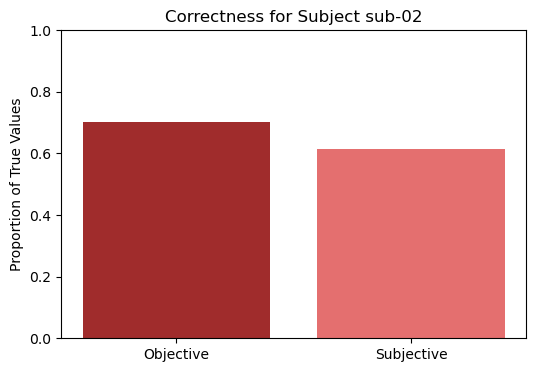

Subject sub-03:
  Objective Correctness: 0.68694 (305/444)
  Subjective Correctness: 0.61937 (275/444)


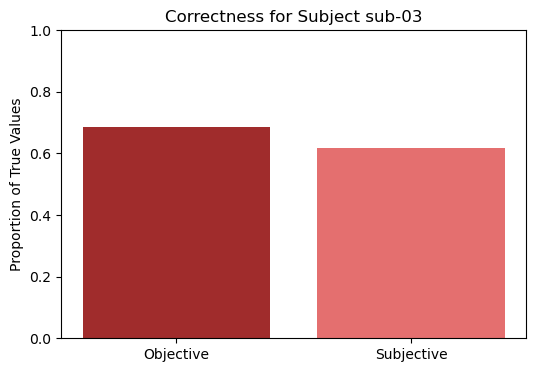

Subject sub-05:
  Objective Correctness: 0.68694 (305/444)
  Subjective Correctness: 0.64414 (286/444)


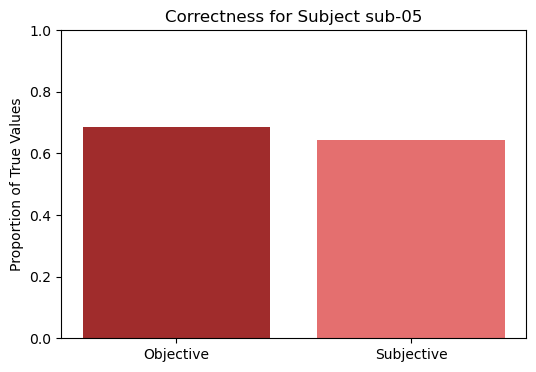

Subject sub-06:
  Objective Correctness: 0.70439 (305/433)
  Subjective Correctness: 0.61663 (267/433)


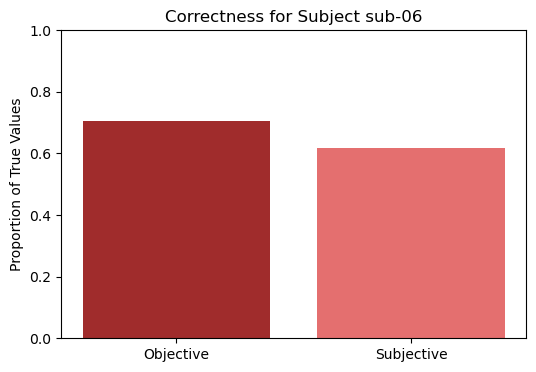

Subject sub-07:
  Objective Correctness: 0.60360 (268/444)
  Subjective Correctness: 0.57432 (255/444)


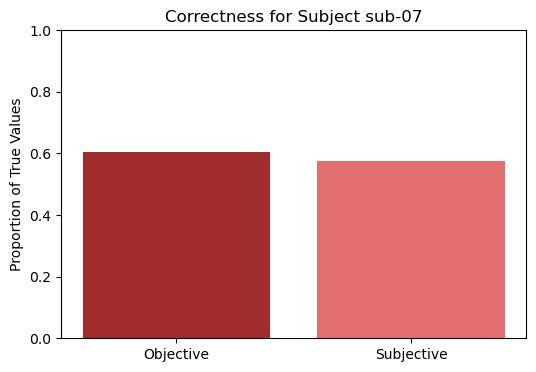

Subject sub-08:
  Objective Correctness: 0.63208 (268/424)
  Subjective Correctness: 0.58962 (250/424)


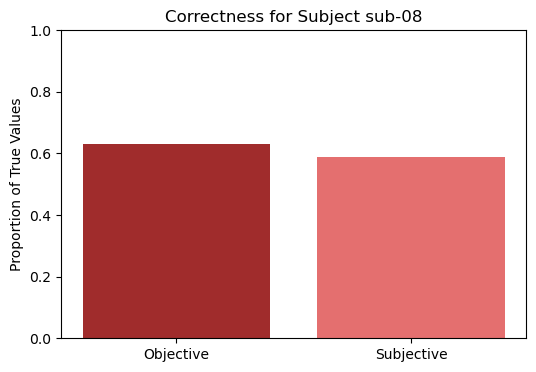

Subject sub-09:
  Objective Correctness: 0.64908 (283/436)
  Subjective Correctness: 0.56193 (245/436)


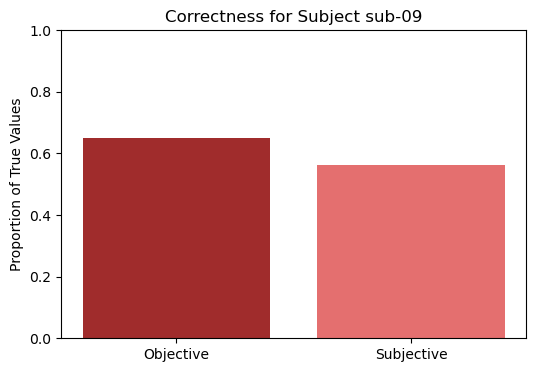

Subject sub-11:
  Objective Correctness: 0.79817 (348/436)
  Subjective Correctness: 0.69954 (305/436)


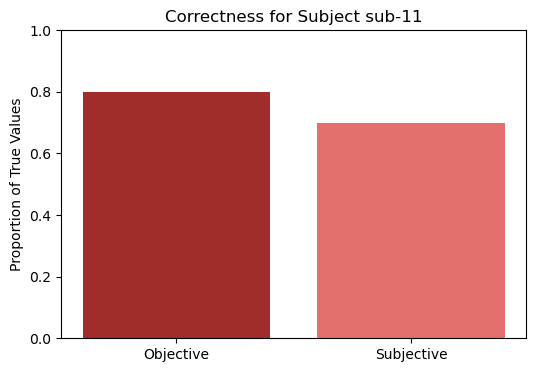

Subject sub-12:
  Objective Correctness: 0.67489 (301/446)
  Subjective Correctness: 0.57623 (257/446)


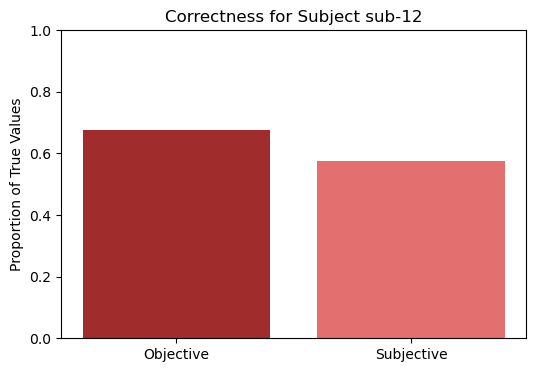

Subject sub-13:
  Objective Correctness: 0.66667 (296/444)
  Subjective Correctness: 0.61261 (272/444)


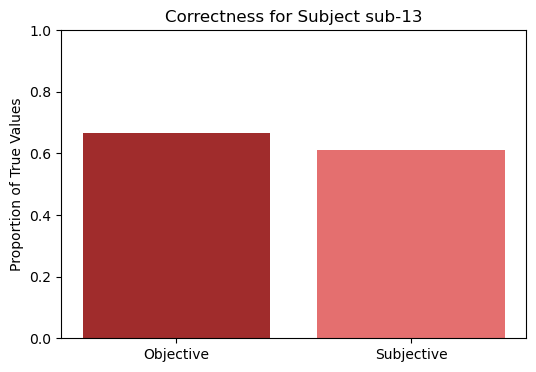

Subject sub-14:
  Objective Correctness: 0.61693 (277/449)
  Subjective Correctness: 0.57238 (257/449)


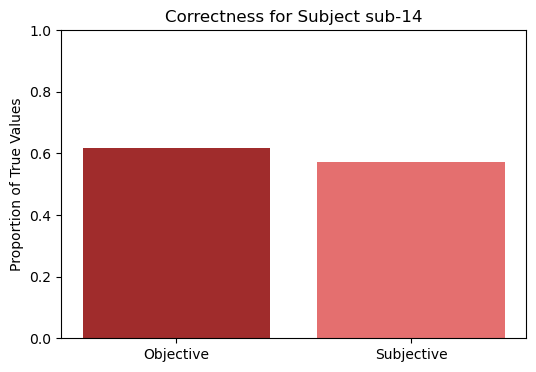

Subject sub-15:
  Objective Correctness: 0.66366 (294/443)
  Subjective Correctness: 0.58916 (261/443)


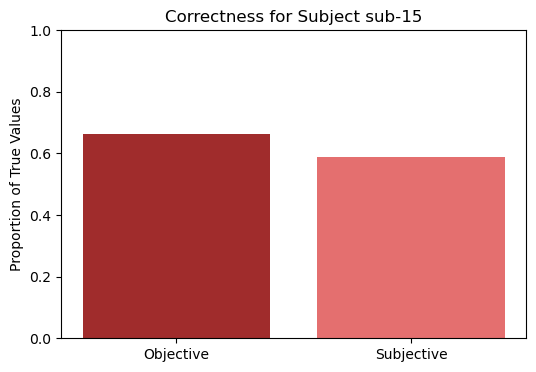

Subject sub-16:
  Objective Correctness: 0.65789 (275/418)
  Subjective Correctness: 0.61005 (255/418)


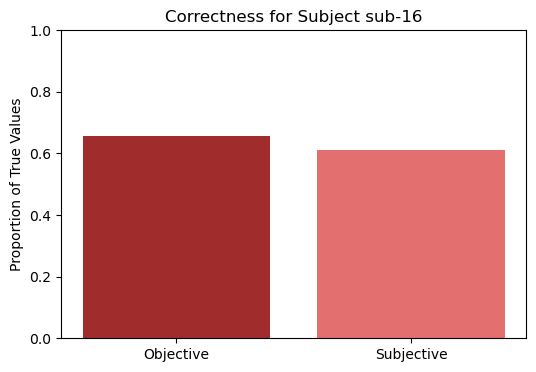

Subject sub-17:
  Objective Correctness: 0.61161 (274/448)
  Subjective Correctness: 0.59375 (266/448)


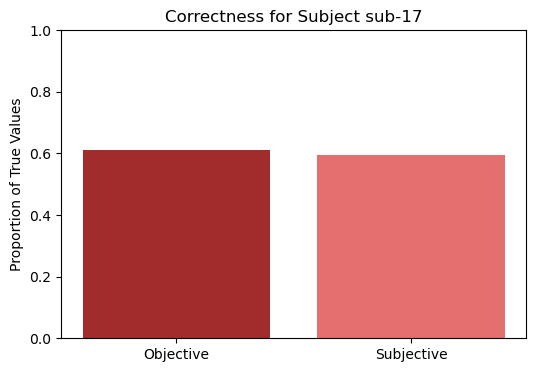

Subject sub-18:
  Objective Correctness: 0.69615 (307/441)
  Subjective Correctness: 0.63946 (282/441)


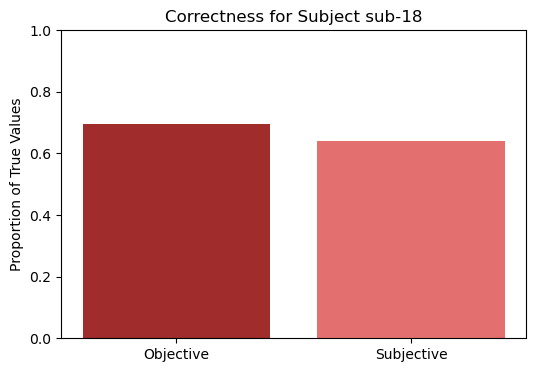

Subject sub-19:
  Objective Correctness: 0.59778 (269/450)
  Subjective Correctness: 0.57556 (259/450)


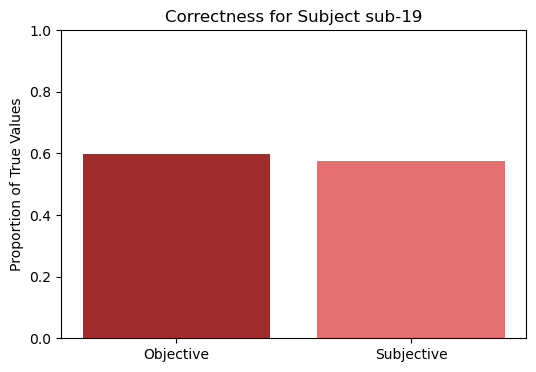

Subject sub-20:
  Objective Correctness: 0.75281 (335/445)
  Subjective Correctness: 0.67416 (300/445)


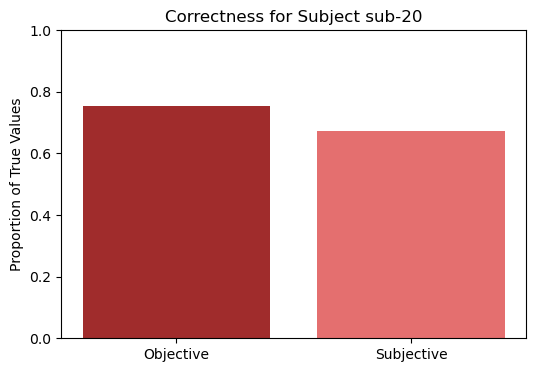

Subject sub-21:
  Objective Correctness: 0.59681 (262/439)
  Subjective Correctness: 0.55809 (245/439)


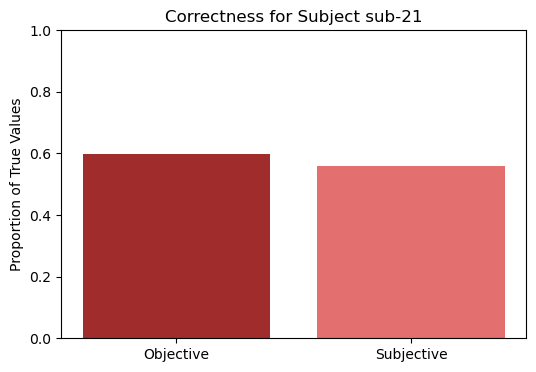


Correctness summary saved to:
/project/3025011.01/derivatives/rlt/analysis/correctness_summary.csv


In [14]:
def calculate_and_plot_correctness(df, split_by_subject=False):
    
    output_dir = r'/project/3025011.01/derivatives/rlt/analysis/' # r'\\fileserver.dccn.nl\project\3025011.01\derivatives\rlt\analysis'
    output_file = os.path.join(output_dir, 'correctness_summary.csv')
    
    # Check if the required columns exist
    if {'objectively_correct', 'subjectively_correct', 'subject_id'}.issubset(df.columns):
        # Drop first 8 rows for objective correctness
        df_filtered = df.copy()

        try:
            # Convert columns to boolean
            df_filtered = df_filtered[df_filtered['objectively_correct'] != "Late"].copy()
            df_filtered['objectively_correct'] = df_filtered['objectively_correct'].map(lambda x: str(x).strip().lower() == 'true')
            df = df[df['objectively_correct'] != "Late"].copy()
            df['subjectively_correct'] = df['subjectively_correct'].map(lambda x: str(x).strip().lower() == 'true')

            if split_by_subject:
                results = []
                for subject in df['subject_id'].unique():
                    df_subject = df[df['subject_id'] == subject]
                    df_filtered_subject = df_filtered[df_filtered['subject_id'] == subject]

                    # Calculate proportions and counts
                    objective_true_count = df_filtered_subject['objectively_correct'].sum()
                    objective_total = df_filtered_subject['objectively_correct'].count()
                    subjective_true_count = df_subject['subjectively_correct'].sum()
                    subjective_total = df_subject['subjectively_correct'].count()

                    objective_proportion = objective_true_count / objective_total if objective_total else 0
                    subjective_proportion = subjective_true_count / subjective_total if subjective_total else 0

                    print(f"Subject {subject}:")
                    print(f"  Objective Correctness: {objective_proportion:.5f} ({objective_true_count}/{objective_total})")
                    print(f"  Subjective Correctness: {subjective_proportion:.5f} ({subjective_true_count}/{subjective_total})")

                    plt.figure(figsize=(6, 4))
                    plt.bar(['Objective', 'Subjective'], [objective_proportion, subjective_proportion], color=["#a02c2c", "#e46f6f"])
                    plt.ylim(0, 1)
                    plt.ylabel('Proportion of True Values')
                    plt.title(f'Correctness for Subject {subject}')
                    plt.show()

                    # Append to results
                    results.append({
                        'subject_id': subject,
                        'objective_correctness': objective_proportion,
                        'subjective_correctness': subjective_proportion,
                        'responses_n': objective_total
                    })

                # Save results to CSV if we are looking at all subjects
                results_df = pd.DataFrame(results)
                results_df.to_csv(output_file, index=False)
                print(f"\nCorrectness summary saved to:\n{output_file}")
            else:
                # Calculate overall proportions and counts
                objective_true_count = df_filtered['objectively_correct'].sum()
                objective_total = df_filtered['objectively_correct'].count()
                subjective_true_count = df['subjectively_correct'].sum()
                subjective_total = df['subjectively_correct'].count()

                objective_proportion = objective_true_count / objective_total if objective_total else 0
                subjective_proportion = subjective_true_count / subjective_total if subjective_total else 0

                print("Overall:")
                print(f"  Objective Correctness: {objective_proportion:.5f} ({objective_true_count}/{objective_total})")
                print(f"  Subjective Correctness: {subjective_proportion:.5f} ({subjective_true_count}/{subjective_total})")

                plt.figure(figsize=(6, 4))
                plt.bar(['Objective', 'Subjective'], [objective_proportion, subjective_proportion], color= ["#a02c2c", "#e46f6f"])
                plt.ylim(0, 1)
                plt.ylabel('Proportion of True Values')
                plt.title('Overall Correctness')
                plt.show()

        except Exception as e:
            print(f"Error processing dataframe: {e}")

    else:
        print("The dataframe does not contain the required columns.")


# Example usage
calculate_and_plot_correctness(combined_results_dataframe, split_by_subject=True)

## Volatile vs stable performance ##

Overall:
  Objective Accuracy for Stable Blocks: 0.69583
  Objective Accuracy for Volatile Blocks: 0.65271


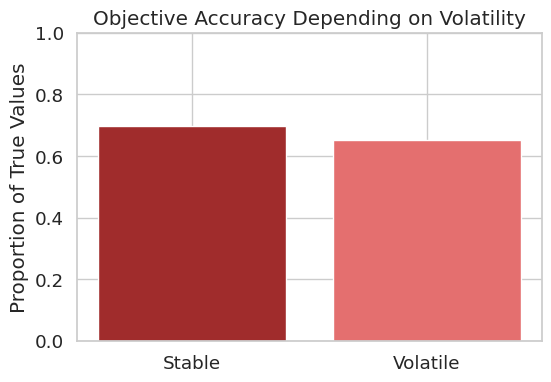

In [34]:
def calculate_accuracy_by_volatility(df: pd.DataFrame, split_by_subject: bool = False):
    if 'volatility' not in df.columns or 'objectively_correct' not in df.columns:
        raise ValueError("DataFrame must contain 'volatility' and 'objectively_correct' columns")
    
    df = df[df['objectively_correct'] != "Late"].copy()
    df['objectively_correct'] = df['objectively_correct'].map(lambda x: str(x).strip().lower() == 'true')

    # Define the path to the correctness CSV file
    output_file = r'/project/3025011.01/derivatives/rlt/analysis/correctness_summary.csv' # r'\\fileserver.dccn.nl\project\3025011.01\derivatives\rlt\analysis\correctness_summary.csv'


    if split_by_subject and 'subject_id' in df.columns:

                # Try to load the existing CSV if it exists
        try:
            correctness_df = pd.read_csv(output_file)
        except FileNotFoundError:
            print(f"Warning: {output_file} not found. Skipping CSV update.")
            correctness_df = pd.DataFrame()

        updated_rows = []

        for subject in sorted(df['subject_id'].unique()):
            df_subject = df[df['subject_id'] == subject]
            stable_accuracy = df_subject[df_subject['volatility'] == 'stable']['objectively_correct'].mean()
            volatile_accuracy = df_subject[df_subject['volatility'] == 'volatile']['objectively_correct'].mean()
            
            print(f"Subject {subject}:\n  Objective Accuracy for Stable Blocks: {stable_accuracy:.5f}\n  Objective Accuracy for Volatile Blocks: {volatile_accuracy:.5f}")
            
            plt.figure(figsize=(6, 4))
            plt.bar(['Stable', 'Volatile'], [stable_accuracy, volatile_accuracy], color= ["#a02c2c", "#e46f6f"])
            plt.ylim(0, 1)
            plt.ylabel('Proportion of True Values')
            plt.title(f'Objective Accuracy Depending on Volatility - Subject {subject}')
            plt.show()

            # Store results to update CSV
            updated_rows.append({
                'subject_id': subject,
                'stable_accuracy': stable_accuracy,
                'volatile_accuracy': volatile_accuracy
            })

        # If correctness summary is available, merge updates
        if not correctness_df.empty:
            updated_df = pd.DataFrame(updated_rows)
            correctness_df = pd.merge(correctness_df, updated_df, on='subject_id', how='left')
            correctness_df.to_csv(output_file, index=False)
            print(f"\nUpdated correctness summary saved to:\n{output_file}")

    else:
        stable_accuracy = df[df['volatility'] == 'stable']['objectively_correct'].mean()
        volatile_accuracy = df[df['volatility'] == 'volatile']['objectively_correct'].mean()
        
        print(f"Overall:\n  Objective Accuracy for Stable Blocks: {stable_accuracy:.5f}\n  Objective Accuracy for Volatile Blocks: {volatile_accuracy:.5f}")
        
        plt.figure(figsize=(6, 4))
        plt.bar(['Stable', 'Volatile'], [stable_accuracy, volatile_accuracy], color= ["#a02c2c", "#e46f6f"])
        plt.ylim(0, 1)
        plt.ylabel('Proportion of True Values')
        plt.title('Objective Accuracy Depending on Volatility')
        plt.show()

# Example usage
calculate_accuracy_by_volatility(combined_results_df_objective, split_by_subject=False)

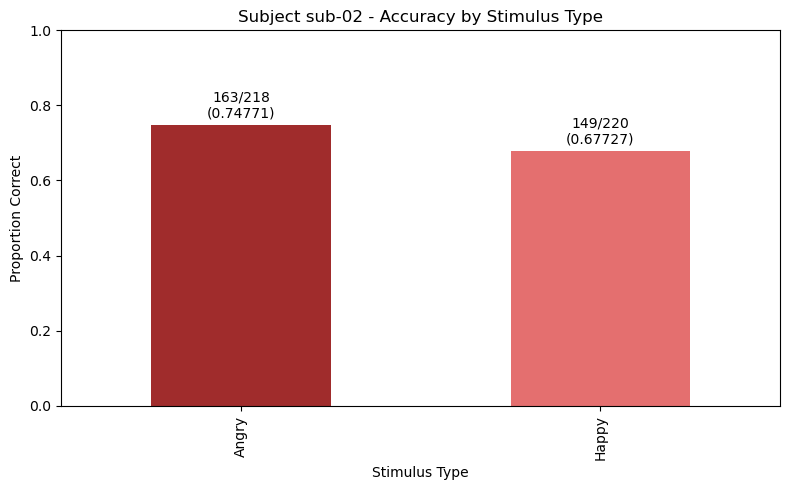

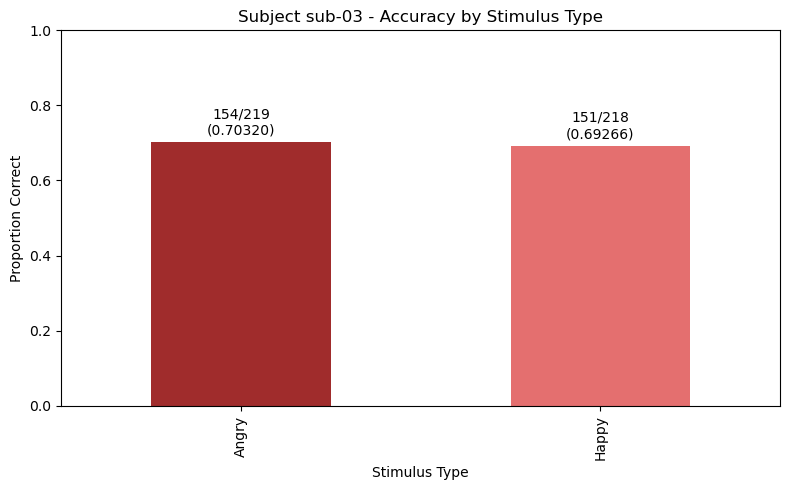

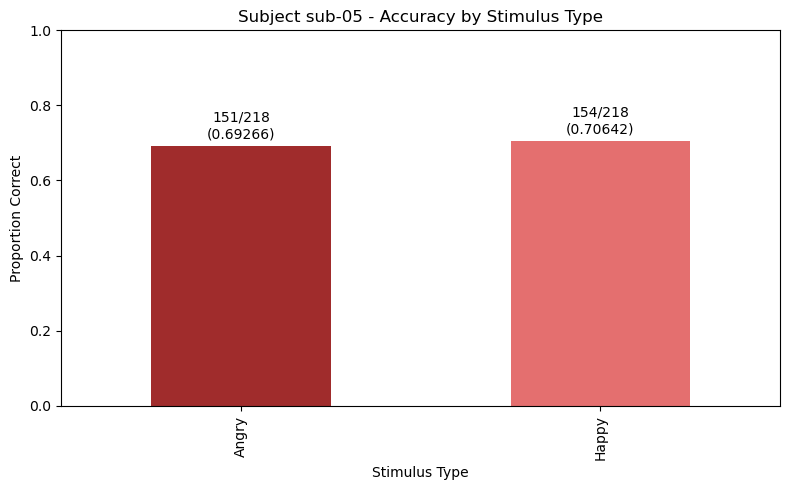

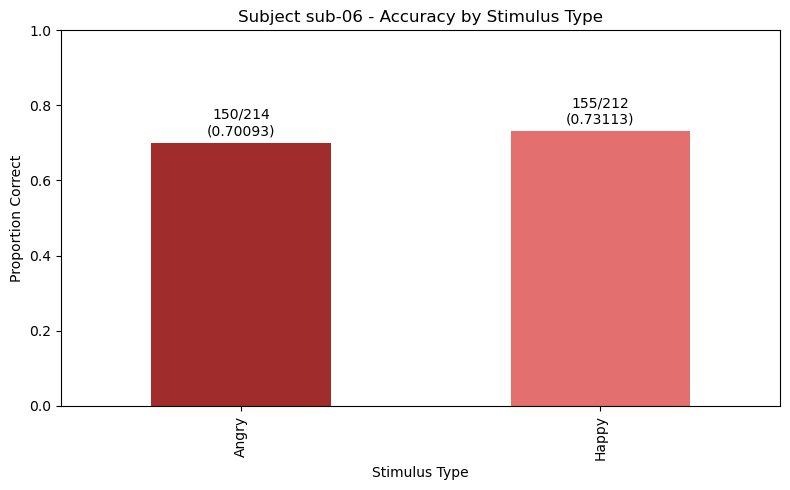

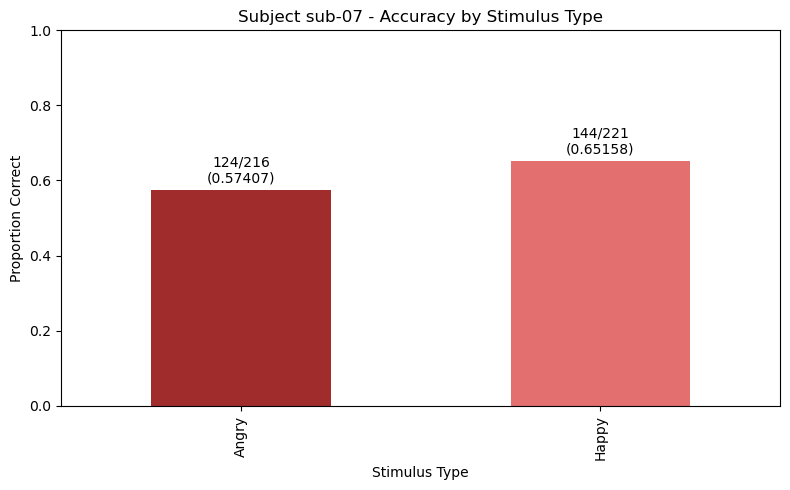

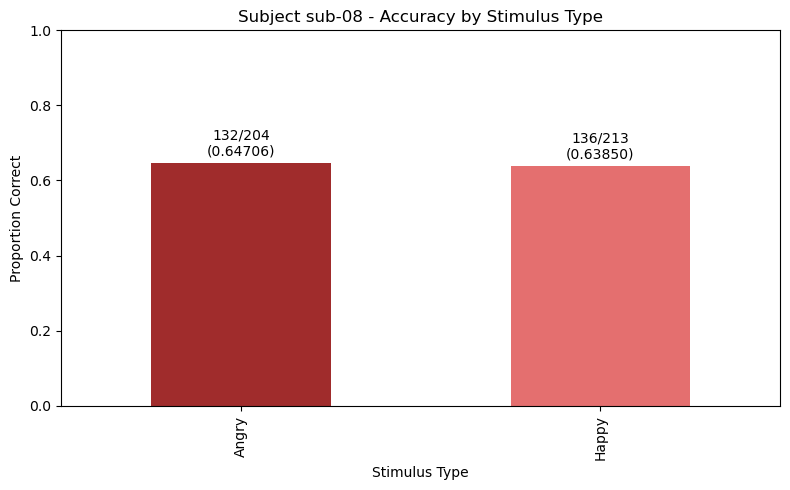

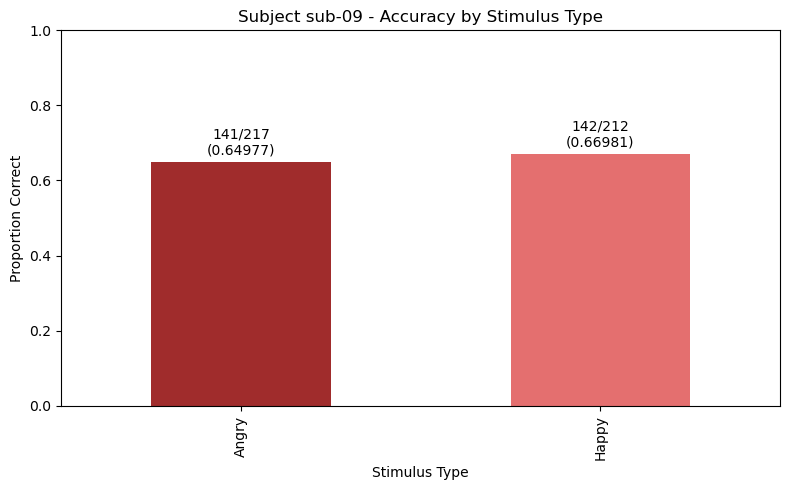

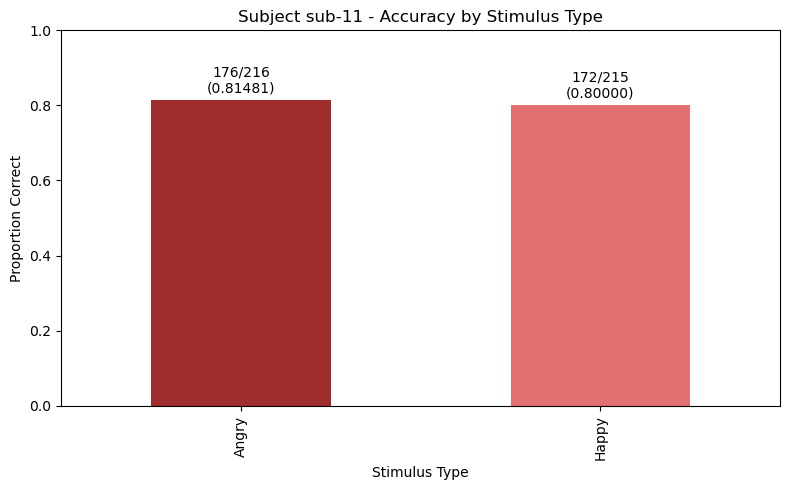

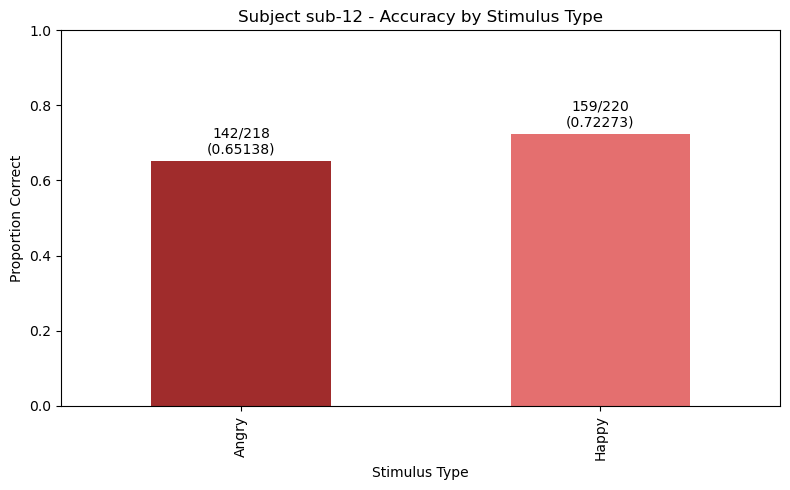

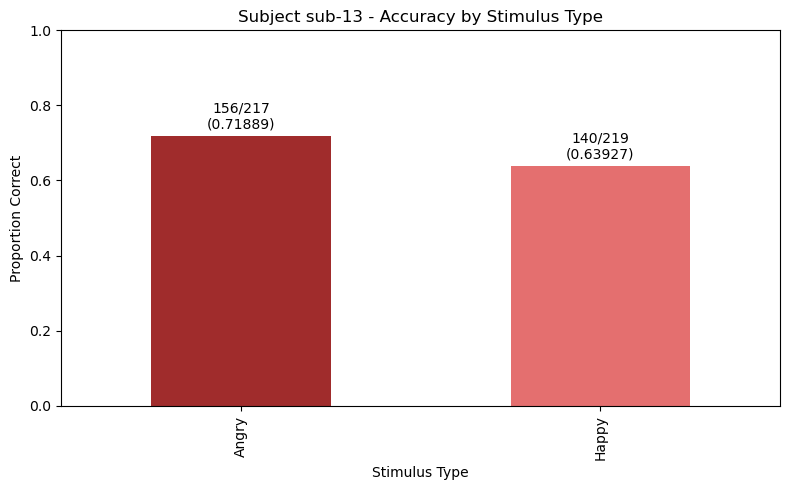

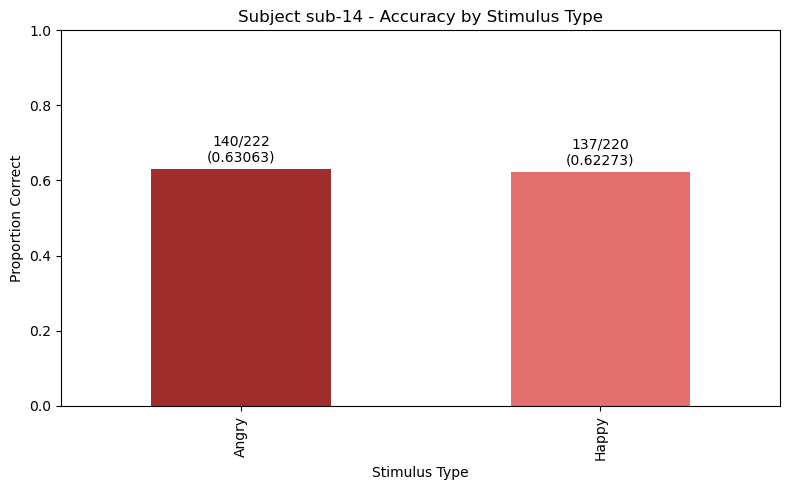

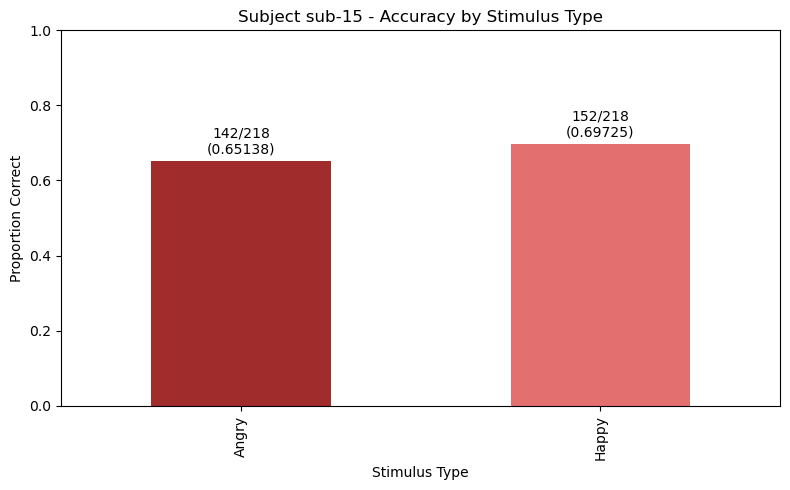

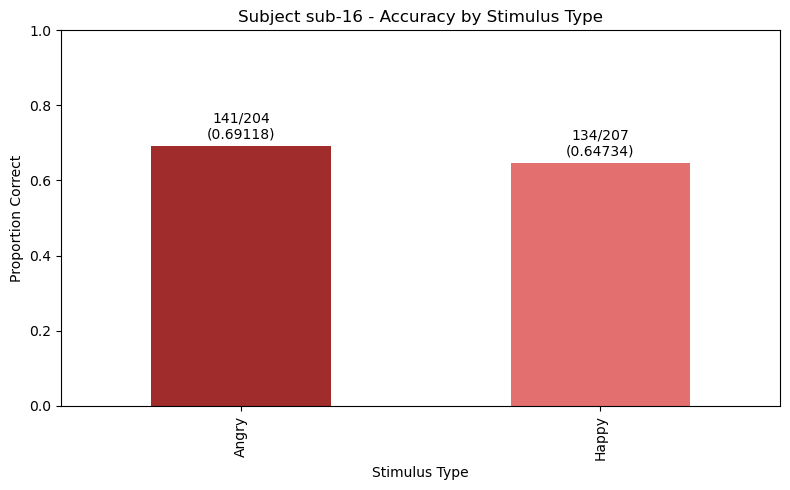

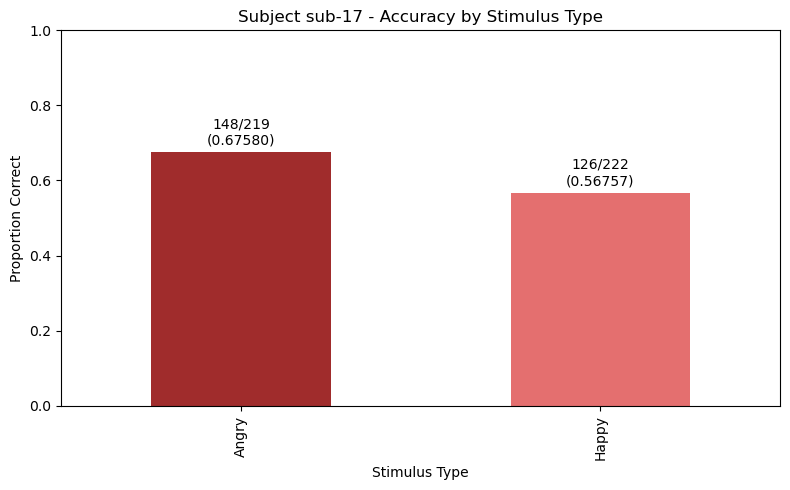

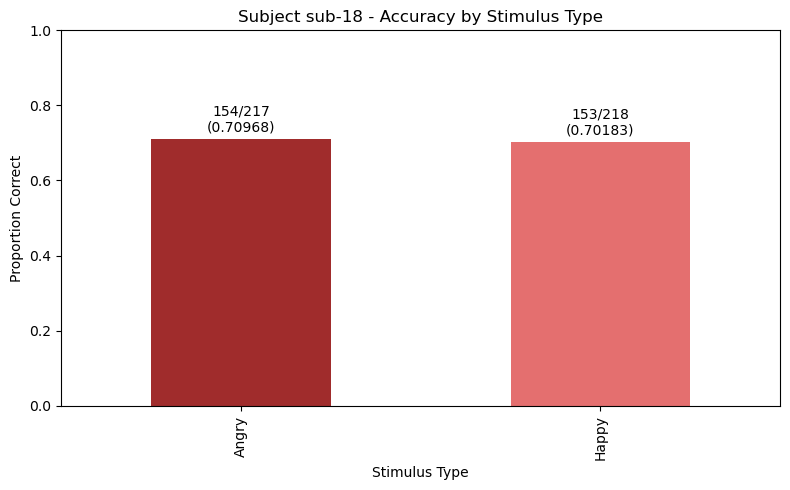

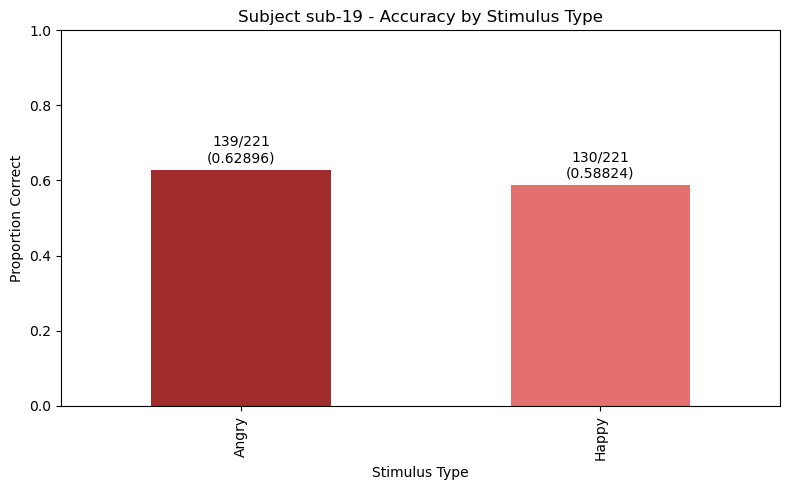

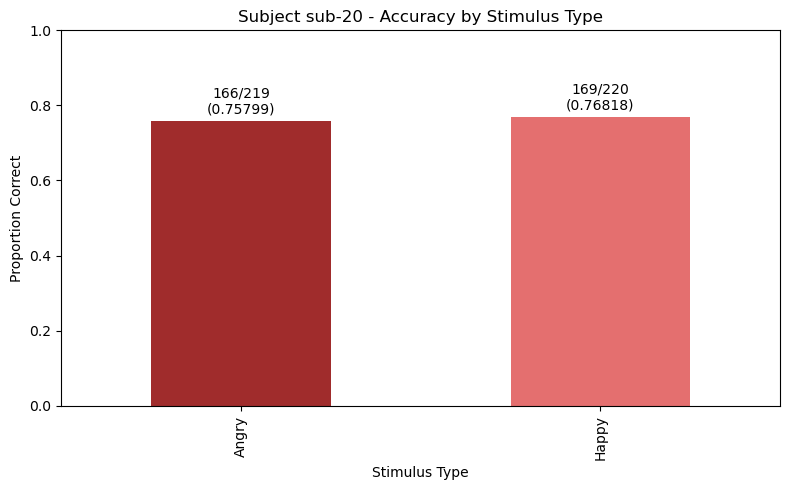

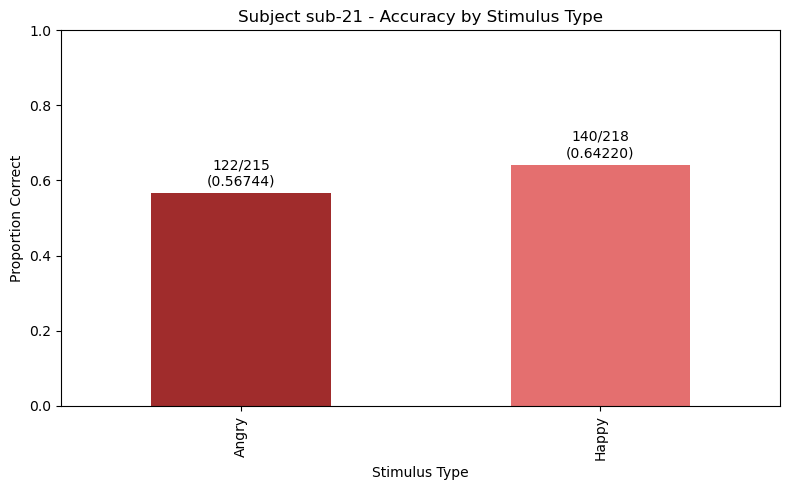


Updated correctness summary saved to:
/project/3025011.01/derivatives/rlt/analysis/correctness_summary.csv


In [16]:
def calculate_emotion_accuracy(df, split_by_subject=False, export=False, export_dir="plots"):
    os.makedirs(export_dir, exist_ok=True)

    df_filtered = df[df['objectively_correct'] != "Late"].copy()
    df_filtered['objectively_correct'] = df_filtered['objectively_correct'].map({'True': 1, 'False': 0})
    df_filtered['stimuli_type'] = df_filtered['stimuli_type'].map({1: 'Angry', 3: 'Happy'})

    output_file = r'/project/3025011.01/derivatives/rlt/analysis/correctness_summary.csv'
    colors = ["#a02c2c", "#e46f6f"]

    if split_by_subject:
        try:
            correctness_df = pd.read_csv(output_file)
        except FileNotFoundError:
            print(f"Warning: {output_file} not found. Skipping CSV update.")
            correctness_df = pd.DataFrame()

        updates = []

        for subject in sorted(df_filtered['subject_id'].unique()):
            subject_df = df_filtered[df_filtered['subject_id'] == subject]
            grouped = subject_df.groupby('stimuli_type')['objectively_correct'].agg(['sum', 'count'])
            grouped['accuracy'] = grouped['sum'] / grouped['count']
            grouped['text'] = grouped.apply(lambda x: f"{int(x['sum'])}/{int(x['count'])}\n({x['accuracy']:.5f})", axis=1)

            fig, ax = plt.subplots(figsize=(8, 5))
            grouped['accuracy'].plot(kind='bar', ax=ax, color=colors[:len(grouped)], title=f'Subject {subject} - Accuracy by Stimulus Type')
            for i, val in enumerate(grouped['text']):
                ax.text(i, grouped['accuracy'].iloc[i] + 0.02, val, ha='center')

            ax.set_ylabel('Proportion Correct')
            ax.set_xlabel('Stimulus Type')
            ax.set_ylim(0, 1)
            plt.tight_layout()

            if export:
                plt.savefig(os.path.join(export_dir, f'subject_{subject}_stimuli_accuracy.png'))
                plt.close()
            else:
                plt.show()

            # Prepare CSV update
            update_row = {'subject_id': subject}
            for stim_type in grouped.index:
                label = stim_type.lower()
                update_row[f'accuracy_{label}'] = grouped.loc[stim_type, 'accuracy']
            updates.append(update_row)

        if not correctness_df.empty:
            update_df = pd.DataFrame(updates)
            correctness_df = pd.merge(correctness_df, update_df, on='subject_id', how='left')
            correctness_df.to_csv(output_file, index=False)
            print(f"\nUpdated correctness summary saved to:\n{output_file}")

    else:
        grouped = df_filtered.groupby('stimuli_type')['objectively_correct'].agg(['sum', 'count'])
        grouped['accuracy'] = grouped['sum'] / grouped['count']
        grouped['text'] = grouped.apply(lambda x: f"{int(x['sum'])}/{int(x['count'])}\n({x['accuracy']:.5f})", axis=1)

        fig, ax = plt.subplots(figsize=(8, 5))
        grouped['accuracy'].plot(kind='bar', ax=ax, color=colors[:len(grouped)], title='Overall Accuracy by Stimulus Type')
        for i, val in enumerate(grouped['text']):
            ax.text(i, grouped['accuracy'].iloc[i] + 0.02, val, ha='center')

        ax.set_ylabel('Proportion Correct')
        ax.set_xlabel('Stimulus Type')
        ax.set_ylim(0, 1)
        plt.tight_layout()

        if export:
            plt.savefig(os.path.join(export_dir, 'overall_stimuli_accuracy.png'))
            plt.close()
        else:
            plt.show()

calculate_emotion_accuracy(combined_results_df_objective, split_by_subject=True)

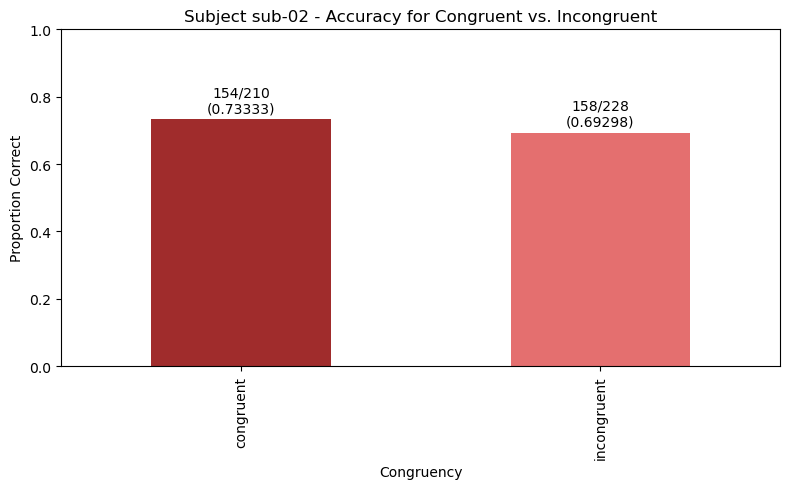

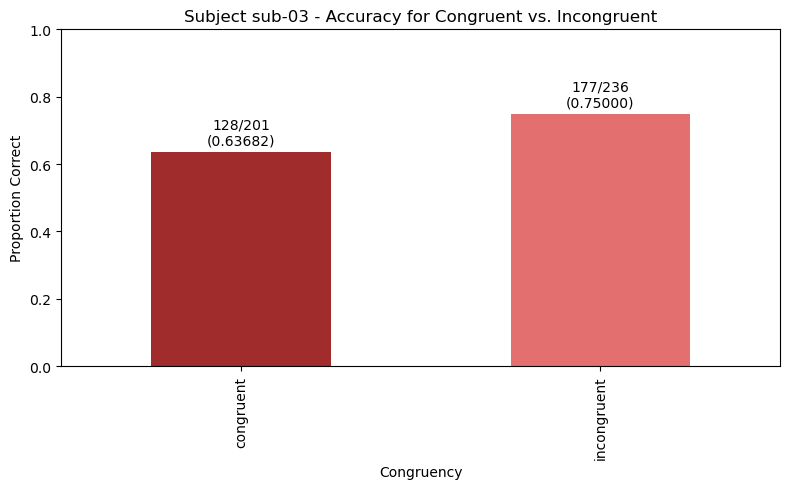

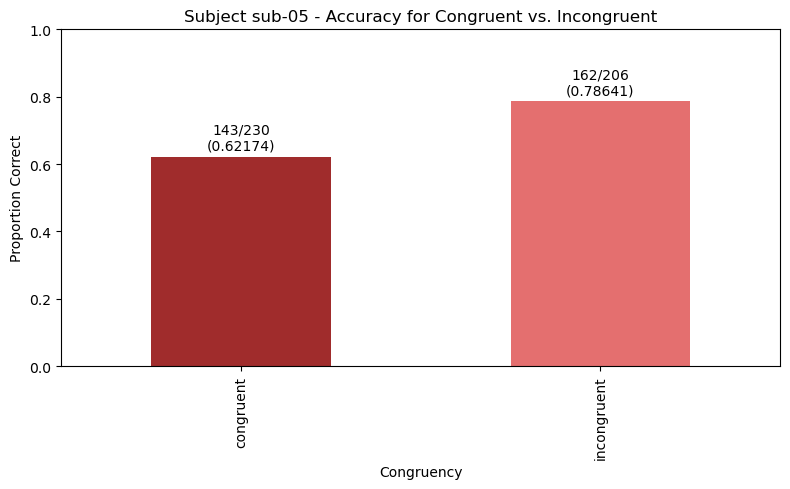

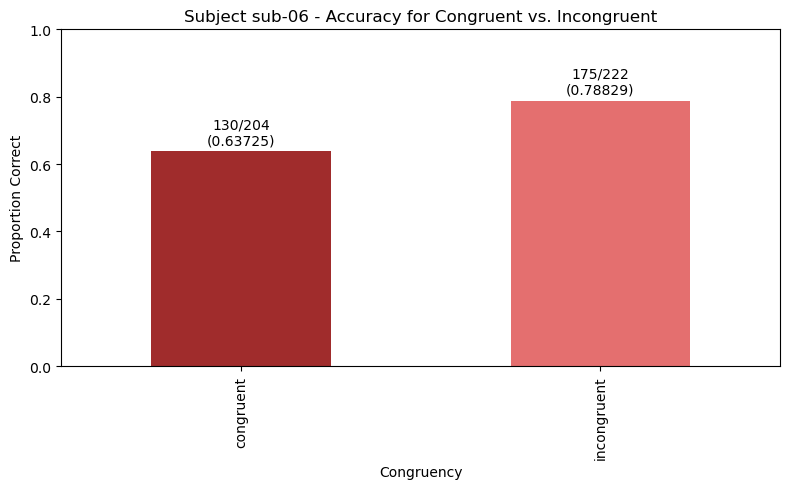

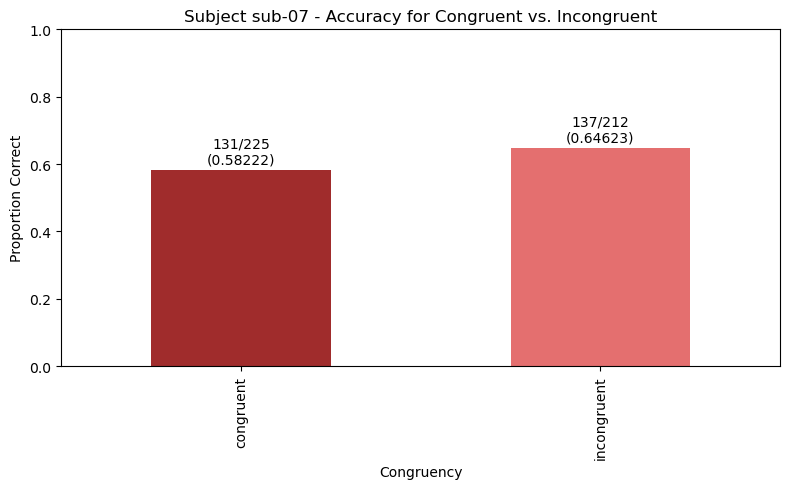

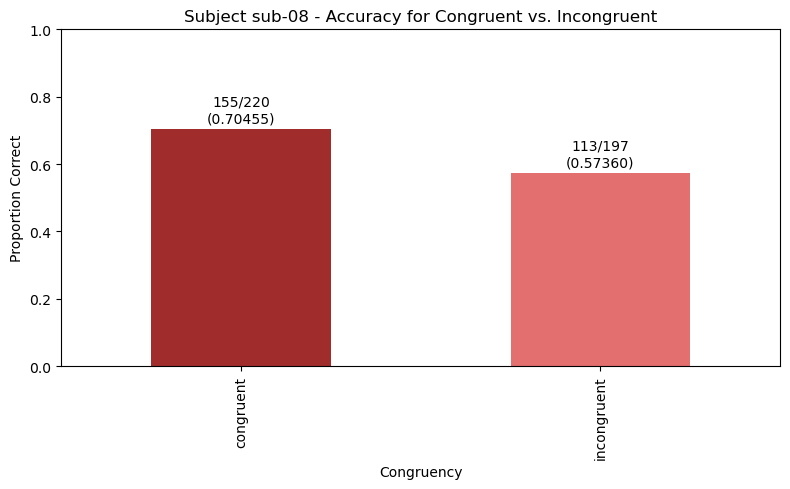

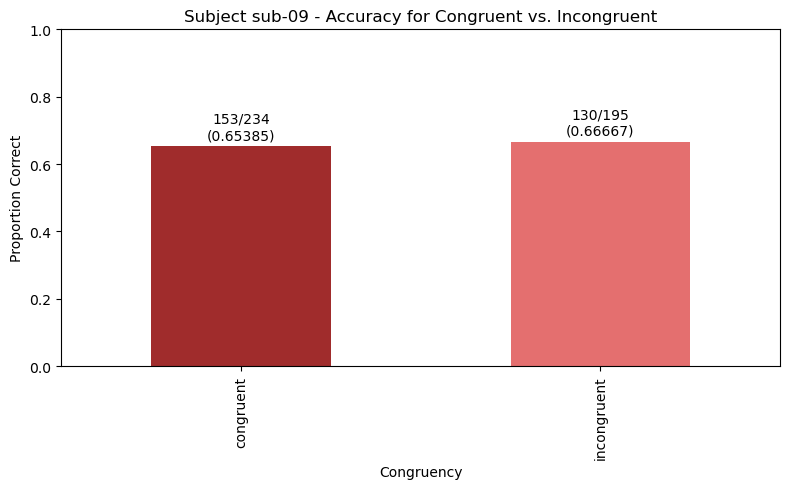

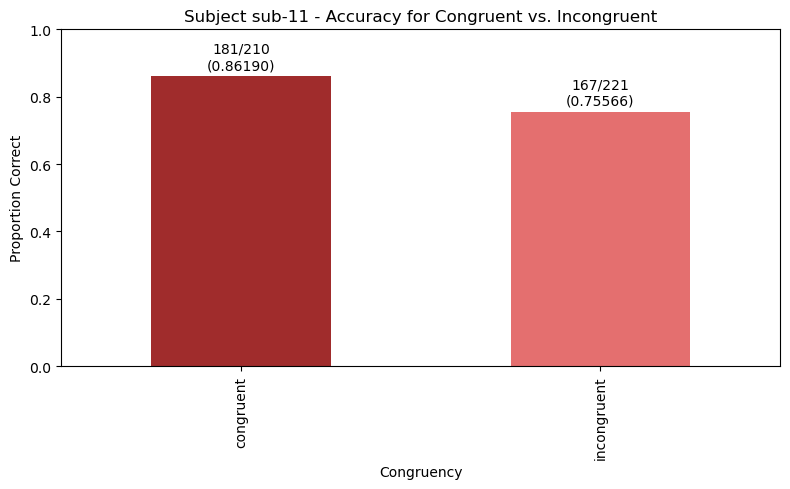

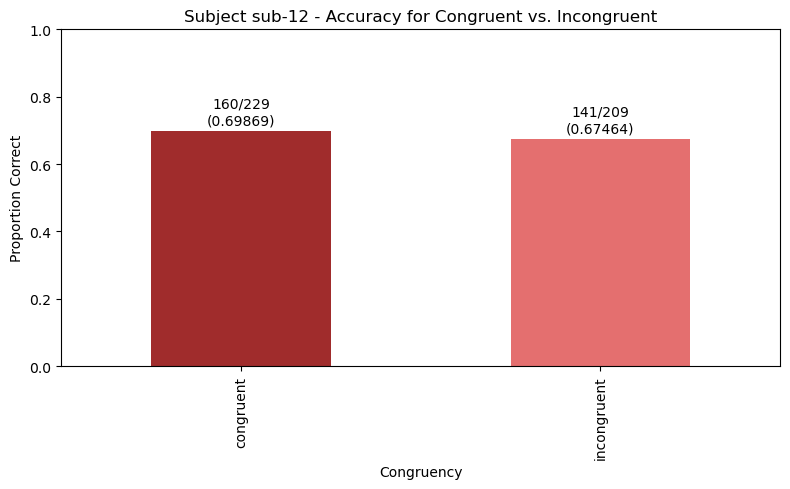

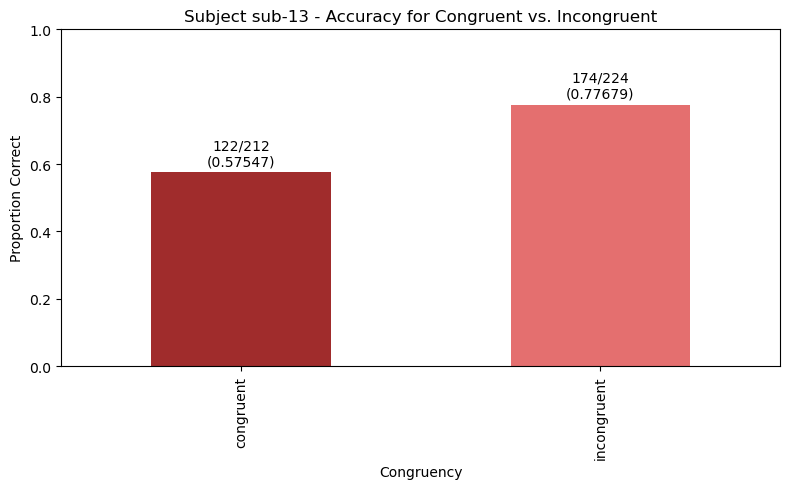

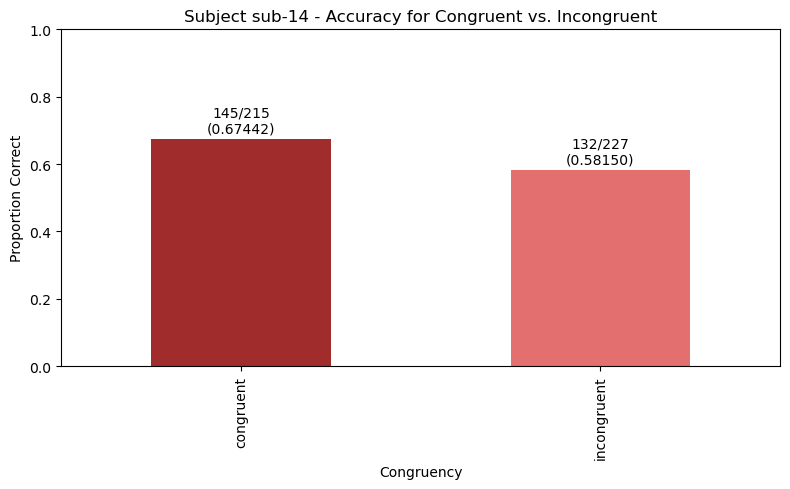

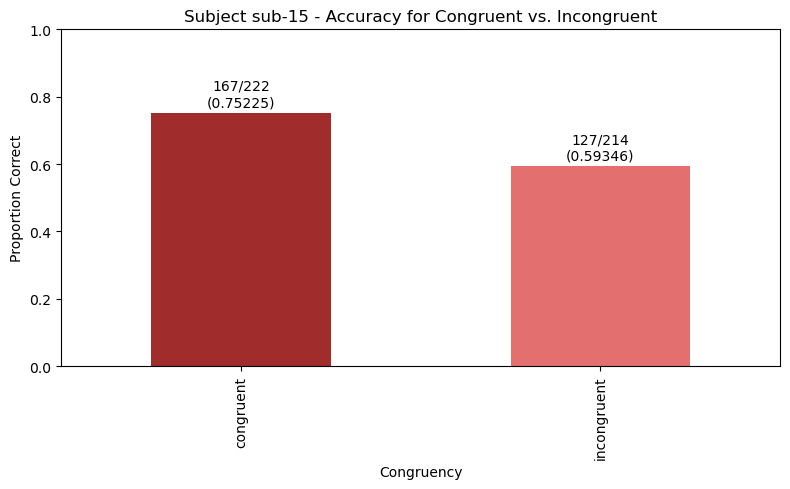

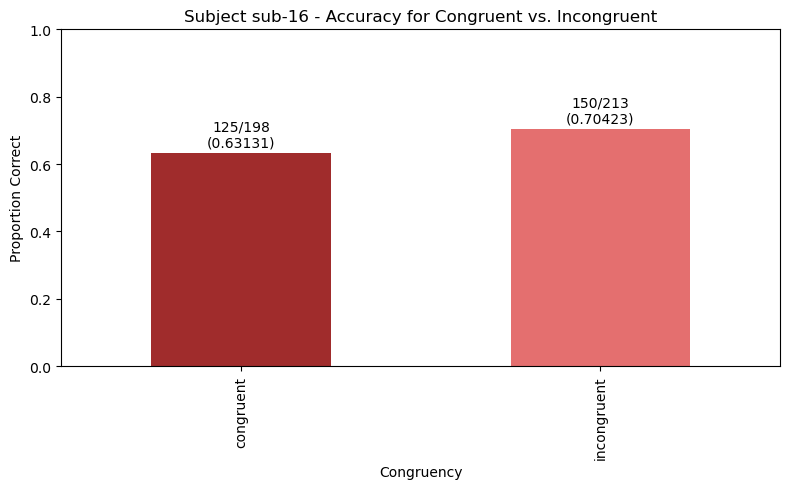

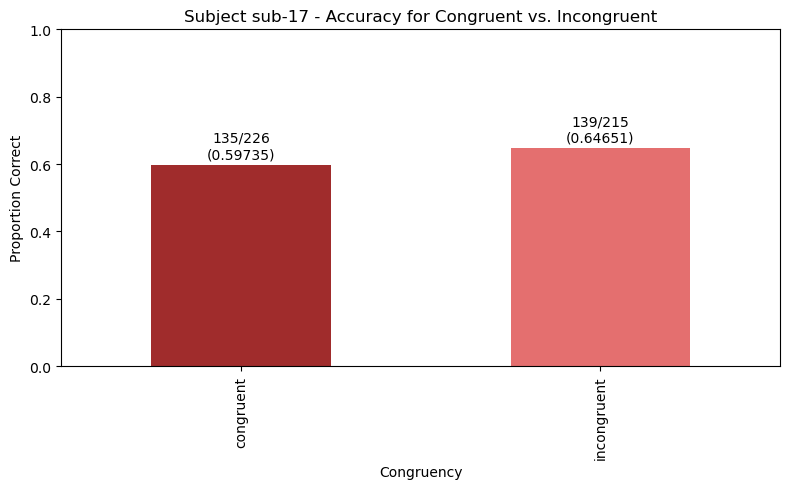

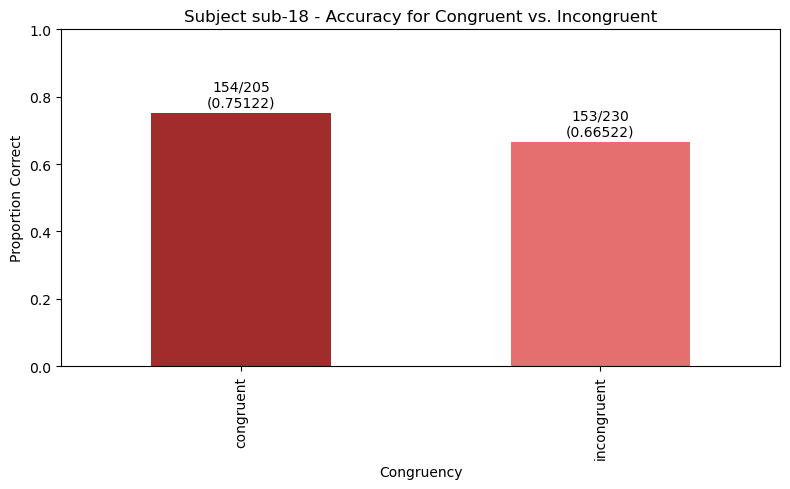

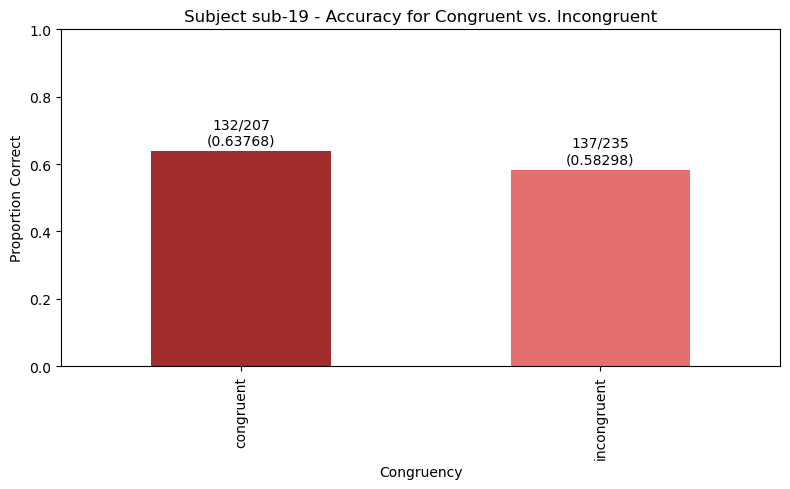

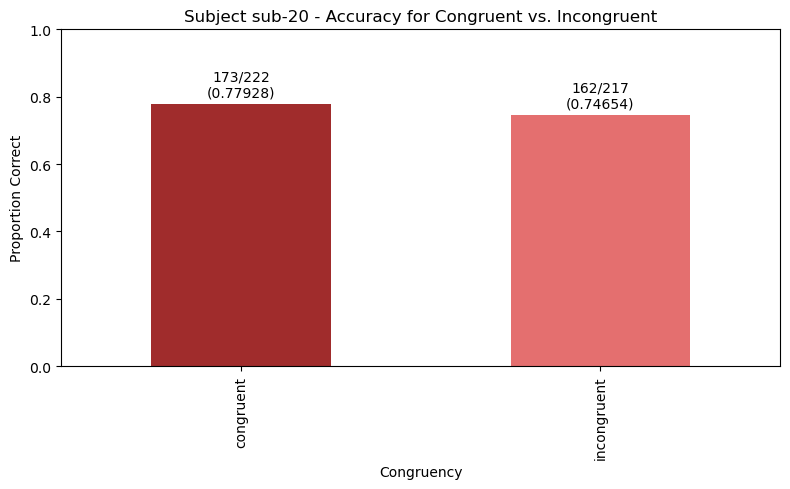

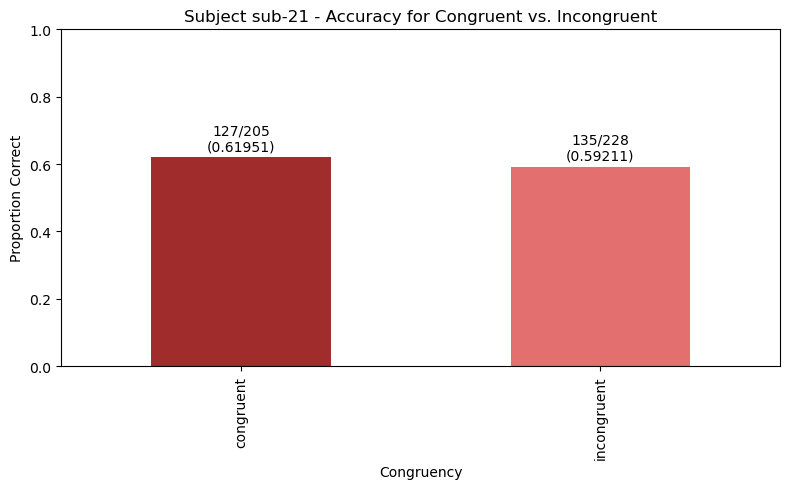


Updated correctness summary saved to:
/project/3025011.01/derivatives/rlt/analysis/correctness_summary.csv


In [17]:
# def calculate_congruency_accuracy(df, split_by_subject=False, export=False, export_dir="plots"):
#     os.makedirs(export_dir, exist_ok=True)

#     df_filtered = df[df['objectively_correct'] != "Late"].copy()
#     df_filtered['objectively_correct'] = df_filtered['objectively_correct'].map({'True': 1, 'False': 0})
#     colors = ['blue', 'red']

#     if split_by_subject:
#         subjects = df_filtered['subject_id'].unique()
#         for subject in subjects:
#             subject_df = df_filtered[df_filtered['subject_id'] == subject]
#             grouped = subject_df.groupby('congruency')['objectively_correct'].agg(['sum', 'count'])
#             grouped['accuracy'] = grouped['sum'] / grouped['count']
#             grouped['text'] = grouped.apply(lambda x: f"{int(x['sum'])}/{int(x['count'])}\n({x['accuracy']:.5f})", axis=1)

#             fig, ax = plt.subplots(figsize=(8, 5))
#             grouped['accuracy'].plot(kind='bar', ax=ax, color=colors, title=f'Subject {subject} - Accuracy for Congruent vs. Incongruent')
#             for i, val in enumerate(grouped['text']):
#                 ax.text(i, grouped['accuracy'][i] + 0.02, val, ha='center')

#             ax.set_ylabel('Proportion Correct')
#             ax.set_xlabel('Congruency')
#             ax.set_ylim(0, 1)
#             plt.tight_layout()

#             if export:
#                 plt.savefig(os.path.join(export_dir, f'subject_{subject}_accuracy.png'))
#                 plt.close()
#             else:
#                 plt.show()
#     else:
#         grouped = df_filtered.groupby('congruency')['objectively_correct'].agg(['sum', 'count'])
#         grouped['accuracy'] = grouped['sum'] / grouped['count']
#         grouped['text'] = grouped.apply(lambda x: f"{int(x['sum'])}/{int(x['count'])}\n({x['accuracy']:.5f})", axis=1)

#         fig, ax = plt.subplots(figsize=(8, 5))
#         grouped['accuracy'].plot(kind='bar', ax=ax, color=colors, title='Overall Accuracy for Congruent vs. Incongruent')
#         for i, val in enumerate(grouped['text']):
#             ax.text(i, grouped['accuracy'][i] + 0.02, val, ha='center')

#         ax.set_ylabel('Proportion Correct')
#         ax.set_xlabel('Congruency')
#         ax.set_ylim(0, 1)
#         plt.tight_layout()

#         if export:
#             plt.savefig(os.path.join(export_dir, 'overall_accuracy.png'))
#             plt.close()
#         else:
#             plt.show()

def calculate_congruency_accuracy(df, split_by_subject=False, export=False, export_dir="plots"):
    os.makedirs(export_dir, exist_ok=True)

    df_filtered = df[df['objectively_correct'] != "Late"].copy()
    df_filtered['objectively_correct'] = df_filtered['objectively_correct'].map({'True': 1, 'False': 0})
    colors = ["#a02c2c", "#e46f6f"]
    # Define path to the shared CSV
    output_file = r'/project/3025011.01/derivatives/rlt/analysis/correctness_summary.csv'

    if split_by_subject:
        subjects = df_filtered['subject_id'].unique()

        # Try to load existing CSV
        try:
            correctness_df = pd.read_csv(output_file)
        except FileNotFoundError:
            print(f"Warning: {output_file} not found. Skipping CSV update.")
            correctness_df = pd.DataFrame()

        updates = []

        for subject in subjects:
            subject_df = df_filtered[df_filtered['subject_id'] == subject]
            grouped = subject_df.groupby('congruency')['objectively_correct'].agg(['sum', 'count'])
            grouped['accuracy'] = grouped['sum'] / grouped['count']
            grouped['text'] = grouped.apply(lambda x: f"{int(x['sum'])}/{int(x['count'])}\n({x['accuracy']:.5f})", axis=1)

            # Plot
            fig, ax = plt.subplots(figsize=(8, 5))
            grouped['accuracy'].plot(kind='bar', ax=ax, color=colors[:len(grouped)], title=f'Subject {subject} - Accuracy for Congruent vs. Incongruent')
            for i, val in enumerate(grouped['text']):
                ax.text(i, grouped['accuracy'].iloc[i] + 0.02, val, ha='center')
            ax.set_ylabel('Proportion Correct')
            ax.set_xlabel('Congruency')
            ax.set_ylim(0, 1)
            plt.tight_layout()

            if export:
                plt.savefig(os.path.join(export_dir, f'subject_{subject}_accuracy.png'))
                plt.close()
            else:
                plt.show()

            # Store results to update CSV
            update_row = {'subject_id': subject}
            for congruency_type in grouped.index:
                acc = grouped.loc[congruency_type, 'accuracy']
                update_row[f'accuracy_{congruency_type.lower()}'] = acc
            updates.append(update_row)

        # Merge updates into the correctness summary
        if not correctness_df.empty:
            update_df = pd.DataFrame(updates)
            correctness_df = pd.merge(correctness_df, update_df, on='subject_id', how='left')
            correctness_df.to_csv(output_file, index=False)
            print(f"\nUpdated correctness summary saved to:\n{output_file}")

    else:
        grouped = df_filtered.groupby('congruency')['objectively_correct'].agg(['sum', 'count'])
        grouped['accuracy'] = grouped['sum'] / grouped['count']
        grouped['text'] = grouped.apply(lambda x: f"{int(x['sum'])}/{int(x['count'])}\n({x['accuracy']:.5f})", axis=1)

        # Plot
        fig, ax = plt.subplots(figsize=(8, 5))
        grouped['accuracy'].plot(kind='bar', ax=ax, color=colors[:len(grouped)], title='Overall Accuracy for Congruent vs. Incongruent')
        for i, val in enumerate(grouped['text']):
            ax.text(i, grouped['accuracy'].iloc[i] + 0.02, val, ha='center')
        ax.set_ylabel('Proportion Correct')
        ax.set_xlabel('Congruency')
        ax.set_ylim(0, 1)
        plt.tight_layout()

        if export:
            plt.savefig(os.path.join(export_dir, 'overall_accuracy.png'))
            plt.close()
        else:
            plt.show()



# Example usage
calculate_congruency_accuracy(combined_results_df_objective, split_by_subject=True)

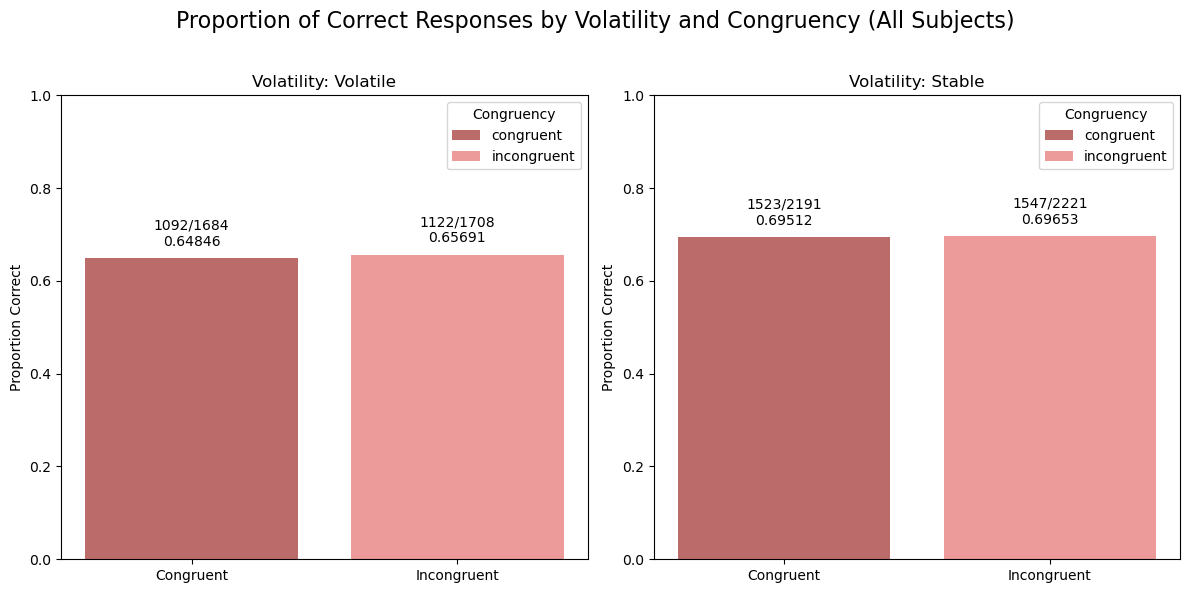

In [18]:
def split_df_by_subject(df):
    """Splits a DataFrame into multiple DataFrames based on unique values in the 'subject_id' column."""
    return {subject_id: group_df for subject_id, group_df in df.groupby("subject_id")}


def plot_volatility_congruency(df, split_by_subject):
    df_filtered = df[df['objectively_correct'] != "Late"].copy()

    # Ensure the objectively_correct column is boolean
    df_filtered['objectively_correct'] = df_filtered['objectively_correct'].astype(str).str.lower().map({'true': True, 'false': False})

    colors = ["#a02c2c", "#e46f6f"]


    if split_by_subject:
        subject_dfs = split_df_by_subject(df_filtered)

        for subject_id, subject_df in subject_dfs.items():
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            fig.suptitle(f'Subject: {subject_id} — Proportion of Correct Responses by Volatility and Congruency', fontsize=14)
            for i, volatility in enumerate(['volatile', 'stable']):
                for j, congruency in enumerate(['congruent', 'incongruent']):
                    # Filter the data based on volatility and congruency
                    filtered_data = subject_df[(subject_df['volatility'] == volatility) & (subject_df['congruency'] == congruency)]
                    total = filtered_data.shape[0]
                    correct = filtered_data['objectively_correct'].sum()
                    proportion_correct = round(correct / total, 5) if total > 0 else 0

                    # Plotting
                    axes[i].bar(congruency, proportion_correct, color=colors[j], alpha=0.7, label=congruency)
                    axes[i].text(congruency, proportion_correct + 0.02, f'{correct}/{total}\n{proportion_correct:.5f}', ha='center', va='bottom')

                axes[i].set_title(f'Volatility: {volatility.capitalize()}')
                axes[i].set_ylabel('Proportion Correct')
                axes[i].set_ylim(0, 1)
                axes[i].set_xticks(['congruent', 'incongruent'])
                axes[i].set_xticklabels(['Congruent', 'Incongruent'])
                axes[i].legend(title='Congruency')

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()

    else:
        # Original single plot for the whole dataset
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle('Proportion of Correct Responses by Volatility and Congruency (All Subjects)', fontsize=16)
        for i, volatility in enumerate(['volatile', 'stable']):
            for j, congruency in enumerate(['congruent', 'incongruent']):
                filtered_data = df_filtered[(df_filtered['volatility'] == volatility) & (df_filtered['congruency'] == congruency)]
                total = filtered_data.shape[0]
                correct = filtered_data['objectively_correct'].sum()
                proportion_correct = round(correct / total, 5) if total > 0 else 0

                axes[i].bar(congruency, proportion_correct, color=colors[j], alpha=0.7, label=congruency)
                axes[i].text(congruency, proportion_correct + 0.02, f'{correct}/{total}\n{proportion_correct:.5f}', ha='center', va='bottom')

            axes[i].set_title(f'Volatility: {volatility.capitalize()}')
            axes[i].set_ylabel('Proportion Correct')
            axes[i].set_ylim(0, 1)
            axes[i].set_xticks(['congruent', 'incongruent'])
            axes[i].set_xticklabels(['Congruent', 'Incongruent'])
            axes[i].legend(title='Congruency')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

plot_volatility_congruency(combined_results_df_objective, split_by_subject=False)

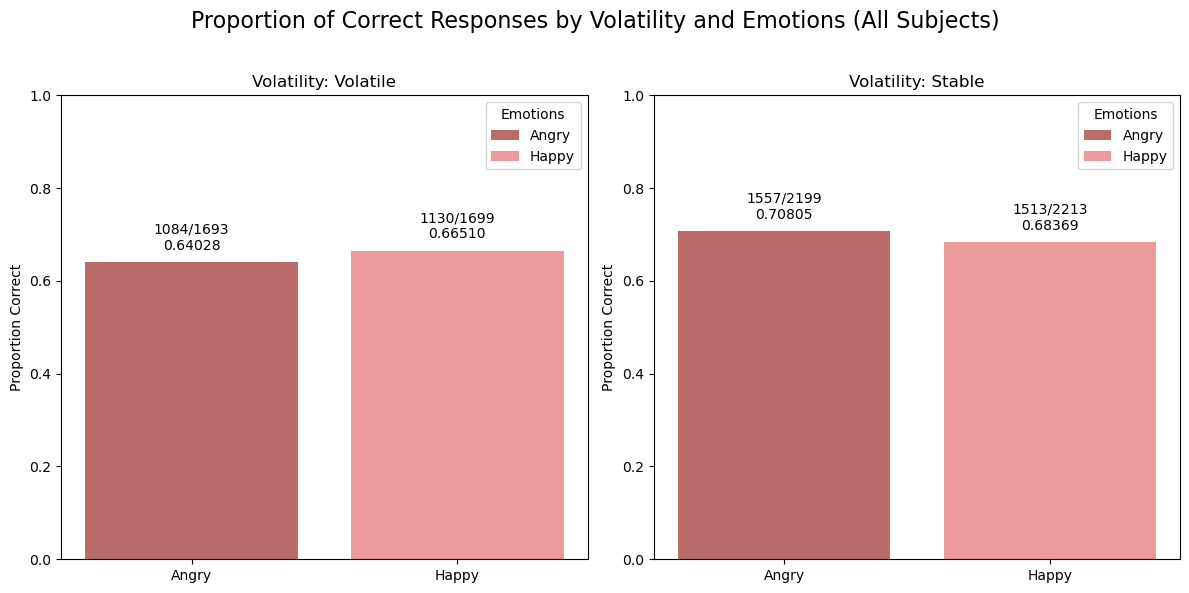

In [19]:
def plot_volatility_emotions(df, split_by_subject):
    
    df_filtered = df[df['objectively_correct'] != "Late"].copy()
    # Ensure the objectively_correct column is boolean
    df_filtered['objectively_correct'] = df_filtered['objectively_correct'].astype(str).str.lower().map({'true': True, 'false': False})
    df_filtered['stimuli_type'] = df_filtered['stimuli_type'].replace({1: 'Angry', 3: 'Happy'})
    
    colors = ["#a02c2c", "#e46f6f"]

    if split_by_subject:
        subject_dfs = split_df_by_subject(df_filtered)

        for subject_id, subject_df in subject_dfs.items():
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            fig.suptitle(f'Subject: {subject_id} — Proportion of Correct Responses by Volatiliy and Emotions', fontsize=14)
            for i, volatility in enumerate(['volatile', 'stable']):
                for j, emotion in enumerate(['Angry', 'Happy']):
                    # Filter the data based on volatility and congruency
                    filtered_data = subject_df[(subject_df['volatility'] == volatility) & (subject_df['stimuli_type'] == emotion)]
                    total = filtered_data.shape[0]
                    correct = filtered_data['objectively_correct'].sum()
                    proportion_correct = round(correct / total, 5) if total > 0 else 0

                    # Plotting
                    axes[i].bar(emotion, proportion_correct, color=colors[j], alpha=0.7, label=emotion)
                    axes[i].text(emotion, proportion_correct + 0.02, f'{correct}/{total}\n{proportion_correct:.5f}', ha='center', va='bottom')

                axes[i].set_title(f'Volatility: {volatility.capitalize()}')
                axes[i].set_ylabel('Proportion Correct')
                axes[i].set_ylim(0, 1)
                axes[i].set_xticks(['Angry', 'Happy'])
                axes[i].set_xticklabels(['Angry', 'Happy'])
                axes[i].legend(title='Emotions')

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()

    else:
        # Original single plot for the whole dataset
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle('Proportion of Correct Responses by Volatility and Emotions (All Subjects)', fontsize=16)
        for i, volatility in enumerate(['volatile', 'stable']):
            for j, emotion in enumerate(['Angry', 'Happy']):
                filtered_data = df_filtered[(df_filtered['volatility'] == volatility) & (df_filtered['stimuli_type'] == emotion)]
                total = filtered_data.shape[0]
                correct = filtered_data['objectively_correct'].sum()
                proportion_correct = round(correct / total, 5) if total > 0 else 0

                axes[i].bar(emotion, proportion_correct, color=colors[j], alpha=0.7, label=emotion)
                axes[i].text(emotion, proportion_correct + 0.02, f'{correct}/{total}\n{proportion_correct:.5f}', ha='center', va='bottom')

            axes[i].set_title(f'Volatility: {volatility.capitalize()}')
            axes[i].set_ylabel('Proportion Correct')
            axes[i].set_ylim(0, 1)
            axes[i].set_xticks(['Angry', 'Happy'])
            axes[i].set_xticklabels(['Angry', 'Happy'])
            axes[i].legend(title='Emotions')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

plot_volatility_emotions(combined_results_df_objective, split_by_subject=False)

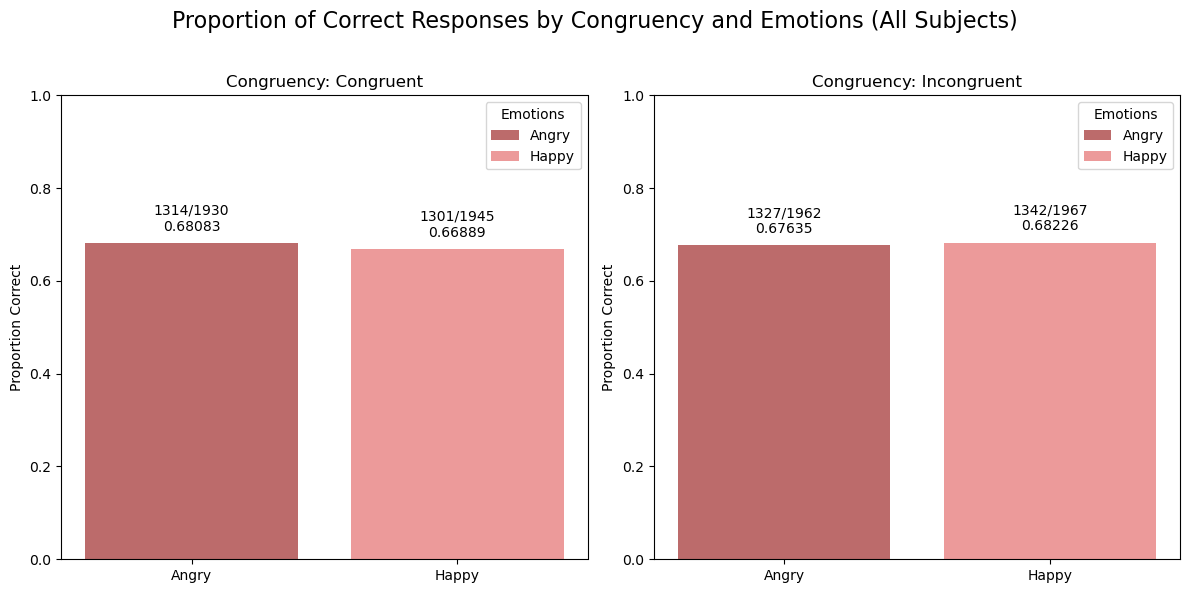

In [20]:
def plot_congruency_emotions(df, split_by_subject):
    df_filtered = df[df['objectively_correct'] != "Late"].copy()
    # Ensure the objectively_correct column is boolean
    df_filtered['objectively_correct'] = df_filtered['objectively_correct'].astype(str).str.lower().map({'true': True, 'false': False})
    df_filtered['stimuli_type'] = df_filtered['stimuli_type'].replace({1: 'Angry', 3: 'Happy'})
    
    colors = ["#a02c2c", "#e46f6f"]

    if split_by_subject:
        subject_dfs = split_df_by_subject(df_filtered)

        for subject_id, subject_df in subject_dfs.items():
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            fig.suptitle(f'Subject: {subject_id} — Proportion of Correct Responses by Congruency and Emotions', fontsize=14)
            for i, congruency in enumerate(['congruent', 'incongruent']):
                for j, emotion in enumerate(['Angry', 'Happy']):
                    # Filter the data based on volatility and congruency
                    filtered_data = subject_df[(subject_df['congruency'] == congruency) & (subject_df['stimuli_type'] == emotion)]
                    total = filtered_data.shape[0]
                    correct = filtered_data['objectively_correct'].sum()
                    proportion_correct = round(correct / total, 5) if total > 0 else 0

                    # Plotting
                    axes[i].bar(emotion, proportion_correct, color=colors[j], alpha=0.7, label=emotion)
                    axes[i].text(emotion, proportion_correct + 0.02, f'{correct}/{total}\n{proportion_correct:.5f}', ha='center', va='bottom')

                axes[i].set_title(f'Congruency: {congruency.capitalize()}')
                axes[i].set_ylabel('Proportion Correct')
                axes[i].set_ylim(0, 1)
                axes[i].set_xticks(['Angry', 'Happy'])
                axes[i].set_xticklabels(['Angry', 'Happy'])
                axes[i].legend(title='Emotions')

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()

    else:
        # Original single plot for the whole dataset
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle('Proportion of Correct Responses by Congruency and Emotions (All Subjects)', fontsize=16)
        for i, congruency in enumerate(['congruent', 'incongruent']):
            for j, emotion in enumerate(['Angry', 'Happy']):
                filtered_data = df_filtered[(df_filtered['congruency'] == congruency) & (df_filtered['stimuli_type'] == emotion)]
                total = filtered_data.shape[0]
                correct = filtered_data['objectively_correct'].sum()
                proportion_correct = round(correct / total, 5) if total > 0 else 0

                axes[i].bar(emotion, proportion_correct, color=colors[j], alpha=0.7, label=emotion)
                axes[i].text(emotion, proportion_correct + 0.02, f'{correct}/{total}\n{proportion_correct:.5f}', ha='center', va='bottom')

            axes[i].set_title(f'Congruency: {congruency.capitalize()}')
            axes[i].set_ylabel('Proportion Correct')
            axes[i].set_ylim(0, 1)
            axes[i].set_xticks(['Angry', 'Happy'])
            axes[i].set_xticklabels(['Angry', 'Happy'])
            axes[i].legend(title='Emotions')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

plot_congruency_emotions(combined_results_df_objective, split_by_subject=False)

## Descriptive pipeline for single files ##

In [21]:
# Load the data into a DataFrame
subject = os.path.join(base_dir, file_name)
print(subject)
df = pd.read_csv(subject, sep=';')

# Check for missing or unusual values
print(df.isnull().sum())
print(df.describe())

# Mean reaction time (RT) for all trials
mean_rt = df['RT_s'].mean()
print(f"Mean Reaction Time: {mean_rt:.2f} seconds")

# Number of correct responses (subjectively and objectively)
subjectively_correct = df['subjectively_correct'].value_counts()
objectively_correct = df['objectively_correct'].value_counts()

print("Subjective Correctness Counts:")
print(subjectively_correct)

print("Objective Correctness Counts:")
print(objectively_correct)

# Mean reward amount
mean_reward = df['reward_amount'].mean()
print(f"Mean Reward Amount: {mean_reward:.2f}")

/project/3025011.01/data/sub-15/ses-03/rl/sub-15_d3_rlt_behavioural_output.csv
trial                    0
emotional_cue_time       0
response                 9
objectively_correct      0
subjectively_correct     0
response_time            0
RT_s                     0
feedback_time            0
stimuli_type             0
iti                      0
probability_condition    0
face_type                0
stimuli_name             0
reward_amount            0
dtype: int64
            trial  emotional_cue_time  response_time        RT_s  \
count  452.000000        4.520000e+02   4.520000e+02  452.000000   
mean   225.500000        1.743005e+09   1.743005e+09    0.696575   
std    130.625419        4.010149e+02   4.010207e+02    0.188832   
min      0.000000        1.743004e+09   1.743004e+09    0.340000   
25%    112.750000        1.743005e+09   1.743005e+09    0.555750   
50%    225.500000        1.743005e+09   1.743005e+09    0.661500   
75%    338.250000        1.743006e+09   1.743006e+09  

In [22]:
# Filter data by stimuli type
angry_trials = df[df['stimuli_type'] == 1]
happy_trials = df[df['stimuli_type'] == 3]

# Calculate mean RT and accuracy for each emotion
mean_rt_angry = angry_trials['RT_s'].mean()
mean_rt_happy = happy_trials['RT_s'].mean()

print(f"Mean RT for Angry Faces: {mean_rt_angry:.2f} seconds")
print(f"Mean RT for Happy Faces: {mean_rt_happy:.2f} seconds")

# Accuracy rates
accuracy_angry = (angry_trials['objectively_correct'] == 'True').mean()
accuracy_happy = (happy_trials['objectively_correct'] == 'True').mean()

print(f"Accuracy for Angry Faces: {accuracy_angry:.2%}")
print(f"Accuracy for Happy Faces: {accuracy_happy:.2%}")


Mean RT for Angry Faces: 0.70 seconds
Mean RT for Happy Faces: 0.69 seconds
Accuracy for Angry Faces: 62.83%
Accuracy for Happy Faces: 67.26%


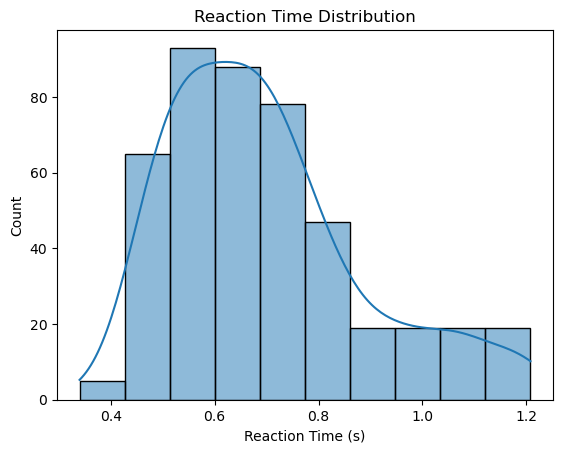

In [23]:
# Plot RT distribution
sns.histplot(df['RT_s'], bins=10, kde=True)
plt.xlabel('Reaction Time (s)')
plt.title('Reaction Time Distribution')
plt.show()


In [24]:
# Count the number of "Late" entries in the 'objectively_correct' column
late_count = (df['objectively_correct'] == 'Late').sum()

# Total number of trials
total_trials = len(df)

# Calculate the proportion of missed responses
late_proportion = late_count / total_trials

# Print the result
print(f"Number of Missed Responses (Late): {late_count}")
print(f"Total Number of Trials: {total_trials}")
print(f"Proportion of Missed Responses: {late_proportion:.2%}")

Number of Missed Responses (Late): 9
Total Number of Trials: 452
Proportion of Missed Responses: 1.99%


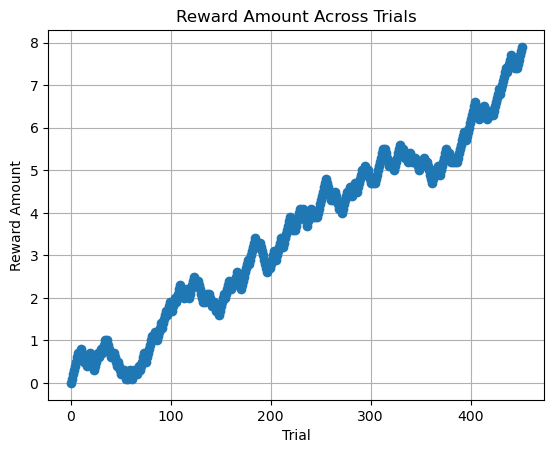

In [25]:
# Plot reward amounts over trials
plt.plot(df['trial'], df['reward_amount'], marker='o')
plt.xlabel('Trial')
plt.ylabel('Reward Amount')
plt.title('Reward Amount Across Trials')
plt.grid()
plt.show()


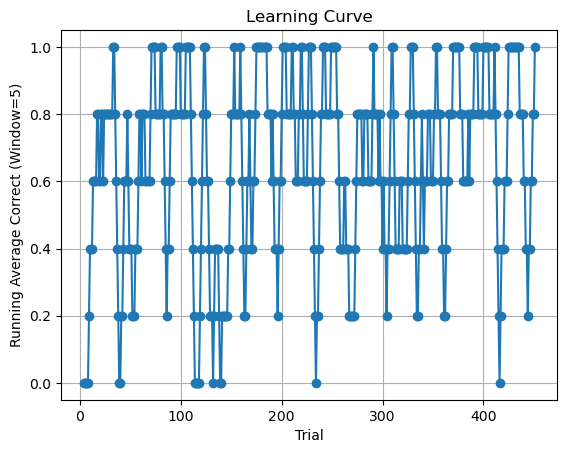

In [26]:
# Create a running average of subjective correctness
df['objectively_correct_binary'] = df['objectively_correct'] == 'True'
df['running_avg_correct'] = df['objectively_correct_binary'].rolling(window=5).mean()

# Plot running average
plt.plot(df['trial'], df['running_avg_correct'], marker='o')
plt.xlabel('Trial')
plt.ylabel('Running Average Correct (Window=5)')
plt.title('Learning Curve')
plt.grid()
plt.show()


In [27]:
# Group by probability condition and calculate mean RT and accuracy
grouped = df.groupby('probability_condition').agg({
    'RT_s': 'mean',
    'objectively_correct_binary': 'mean'
})

print(grouped)


                           RT_s  objectively_correct_binary
probability_condition                                      
20                     0.701896                    0.680180
50                     0.606250                    0.000000
80                     0.694509                    0.644144


Number of Errors: 182


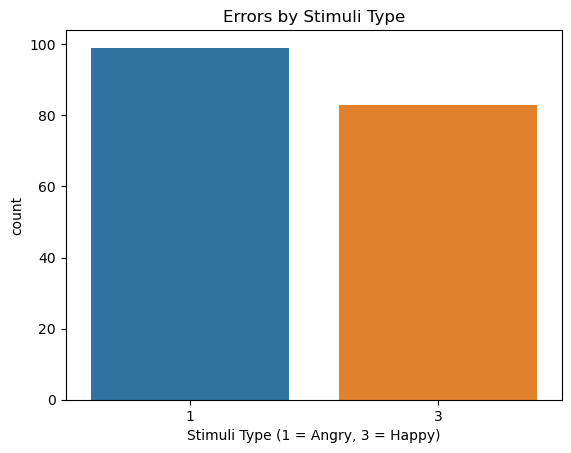

In [28]:
errors = df[df['subjectively_correct'] == 'False']
print(f"Number of Errors: {len(errors)}")

# Plot error distribution by stimuli type
sns.countplot(x='stimuli_type', data=errors)
plt.xlabel('Stimuli Type (1 = Angry, 3 = Happy)')
plt.title('Errors by Stimuli Type')
plt.show()


# More beautiful correctness plots

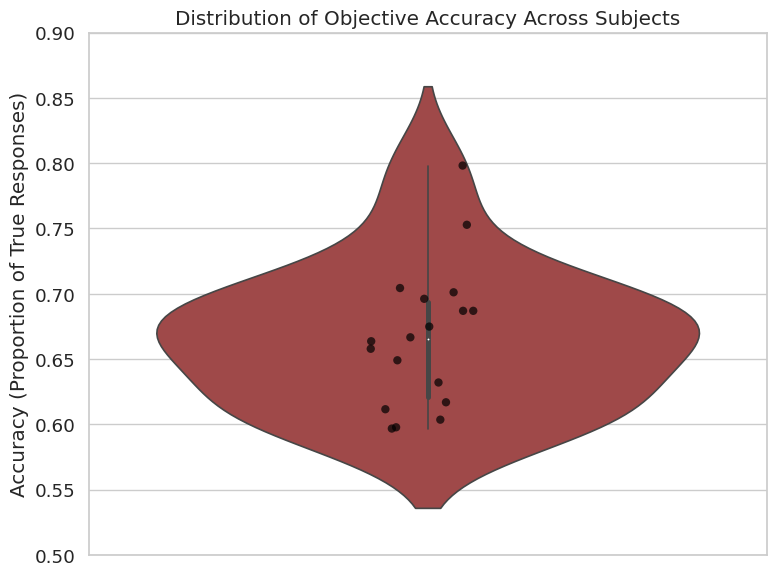

In [29]:
base_dir = r'/project/3025011.01/derivatives/rlt/analysis/' # r'\\fileserver.dccn.nl\project\3025011.01\derivatives\rlt\analysis' # new path for csv files
file_name = r'correctness_summary.csv'  # replace with your actual file name
file_path = os.path.join(base_dir, file_name)

df = pd.read_csv(file_path)

# Set Seaborn theme
sns.set(style='whitegrid', font_scale=1.2)

# Create violin plot
plt.figure(figsize=(8, 6))
ax = sns.violinplot(
    y='objective_correctness',
    data=df,
    inner='box',  # show boxplot inside
    linewidth=1.2,
    color="#ad3b3b"
)

# Overlay individual data points
sns.stripplot(
    y='objective_correctness',
    data=df,
    color='black',
    size=6,
    jitter=True,
    alpha=0.7
)

# Customize plot
plt.title('Distribution of Objective Accuracy Across Subjects')
plt.ylabel('Accuracy (Proportion of True Responses)')
plt.xlabel('')
plt.ylim(0.5, 0.9)  # Adjust if needed
plt.tight_layout()
plt.show()

In [30]:
# lets also do some statistics

stats = df['objective_correctness'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
iqr = df['objective_correctness'].quantile(0.75) - df['objective_correctness'].quantile(0.25)

print("Summary statistics for objective_correctness:")
print(stats)
print(f"IQR: {iqr:.4f}")

Summary statistics for objective_correctness:
mean       0.666527
median     0.665162
std        0.054113
min        0.596811
max        0.798165
count     18.000000
Name: objective_correctness, dtype: float64
IQR: 0.0731


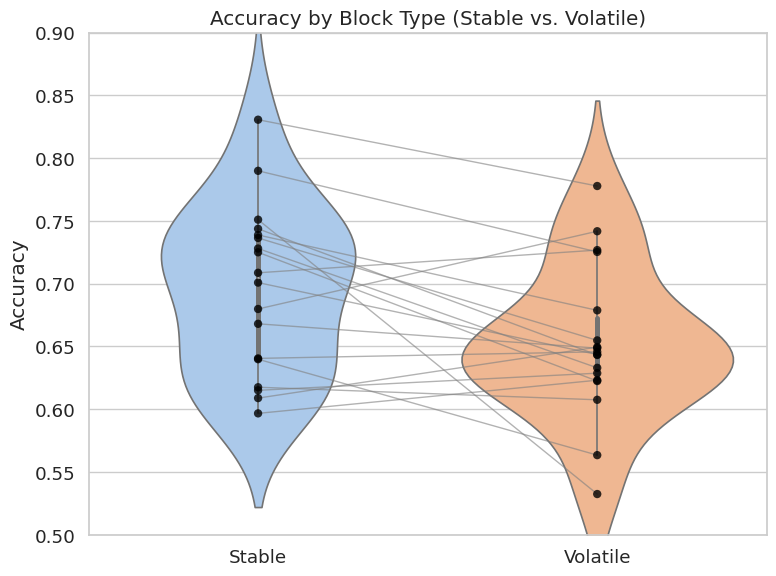

In [31]:
# Check that required columns exist
assert 'stable_accuracy' in df.columns and 'volatile_accuracy' in df.columns, "Required columns missing."

# Melt the dataframe to long format
df_long = df[['subject_id', 'stable_accuracy', 'volatile_accuracy']].melt(
    id_vars='subject_id',
    var_name='block_type',
    value_name='accuracy'
)

# Rename for prettier labels
df_long['block_type'] = df_long['block_type'].replace({
    'stable_accuracy': 'Stable',
    'volatile_accuracy': 'Volatile'
})

# Set seaborn style
sns.set(style='whitegrid', font_scale=1.2)

# Create violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(
    x='block_type',
    y='accuracy',
    data=df_long,
    inner='box',
    linewidth=1.2,
    palette='pastel'
)

# Overlay paired lines per subject
# Create a dictionary mapping each subject's values
for subject_id, sub_df in df_long.groupby('subject_id'):
    if sub_df.shape[0] == 2:  # ensure both Stable and Volatile exist
        plt.plot(
            ['Stable', 'Volatile'],
            sub_df.sort_values('block_type')['accuracy'],
            color='gray',
            alpha=0.6,
            linewidth=1
        )

# Overlay dots
sns.stripplot(
    x='block_type',
    y='accuracy',
    data=df_long,
    color='black',
    size=6,
    jitter=False,
    alpha=0.8
)

# Customize
plt.title('Accuracy by Block Type (Stable vs. Volatile)')
plt.ylabel('Accuracy')
plt.xlabel('')
plt.ylim(0.5, 0.9)  # adjust as needed
plt.tight_layout()
plt.show()

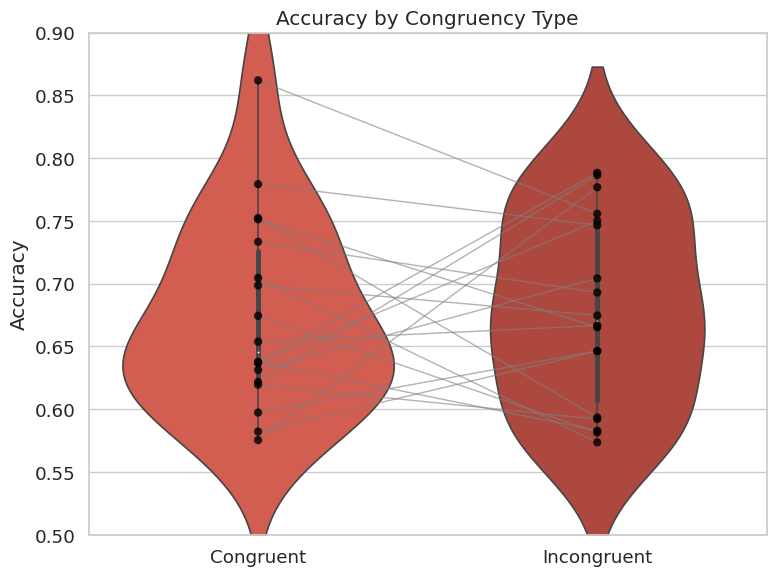

In [32]:
# Melt the dataframe for congruent/incongruent accuracy
df_long = df[['subject_id', 'accuracy_congruent', 'accuracy_incongruent']].melt(
    id_vars='subject_id',
    var_name='congruency',
    value_name='accuracy'
)

# Rename for prettier labels
df_long['congruency'] = df_long['congruency'].replace({
    'accuracy_congruent': 'Congruent',
    'accuracy_incongruent': 'Incongruent'
})

# Set style and color palette
sns.set(style='whitegrid', font_scale=1.2)
red_palette = ['#e74c3c', '#c0392b']  # light red to dark red

# Create violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(
    x='congruency',
    y='accuracy',
    data=df_long,
    inner='box',
    linewidth=1.2,
    palette=red_palette
)

# Connect paired subject points with lines
for subject_id, sub_df in df_long.groupby('subject_id'):
    if sub_df.shape[0] == 2:
        plt.plot(
            ['Congruent', 'Incongruent'],
            sub_df.sort_values('congruency')['accuracy'],
            color='gray',
            alpha=0.6,
            linewidth=1
        )

# Overlay subject dots
sns.stripplot(
    x='congruency',
    y='accuracy',
    data=df_long,
    color='black',
    size=6,
    jitter=False,
    alpha=0.8
)

# Customize plot
plt.title('Accuracy by Congruency Type')
plt.ylabel('Accuracy')
plt.xlabel('')
plt.ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

# Learning rate models

In [33]:
base_dir = r'/project/3025011.01/derivatives/rlt/analysis/' # r'\\fileserver.dccn.nl\project\3025011.01\derivatives\rlt\analysis' # new path for csv files
file_name = r'model_comparison_results_m3_new.csv'  # replace with your actual file name
file_path = os.path.join(base_dir, file_name)

# Load the CSV file
df_learning = pd.read_csv(file_path)  # adjust sep if needed

# Prepare data
ll_cols = ['model0_ll', 'model1_ll', 'model2_ll', 'model3_ll']
model_name_map = {
    'model0': 'Null Model',
    'model1': 'Rescorla-Wagner Model',
    'model2': 'Hybrid Model',
    'model3': 'Hybrid Model (2 Weights)'
}
df_melted = df_learning.melt(id_vars='subject', value_vars=ll_cols, 
                             var_name='model', value_name='log_likelihood')
df_melted['model_key'] = df_melted['model'].str.extract(r'(model\d)').squeeze()
df_melted['Model'] = df_melted['model_key'].map(model_name_map)

# Set consistent model order
model_order = ["Null Model", "Rescorla-Wagner Model", "Hybrid Model", "Hybrid Model (2 Weights)"]

# Plot setup
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='log_likelihood', 
            estimator='mean', ci='sd', palette='Reds_d', errorbar='sd', order=model_order)

# Stripplot (with handle)
strip = sns.stripplot(data=df_melted, x='Model', y='log_likelihood', 
                      color='gray', alpha=0.6, jitter=True, size=5, order=model_order)

# Extract actual plotted x/y coordinates
xy_data = []
for i, artist in enumerate(strip.collections):
    paths = artist.get_offsets()
    xy_data.append(paths)

# Group points per subject
subject_points = {}
for i, model in enumerate(model_order):
    model_data = df_melted[df_melted["Model"] == model].reset_index()
    for j, row in model_data.iterrows():
        subj = row["subject"]
        x, y = xy_data[i][j]
        if subj not in subject_points:
            subject_points[subj] = []
        subject_points[subj].append((x, y))

# Draw subject-wise lines connecting jittered points
for subj, points in subject_points.items():
    if len(points) == len(model_order):
        xs, ys = zip(*sorted(points, key=lambda p: p[0]))
        plt.plot(xs, ys, color='gray', alpha=0.3, linewidth=1)

# Mark subject-wise max likelihood with blue star
for subj, points in subject_points.items():
    if len(points) == len(model_order):
        max_idx = max(range(len(points)), key=lambda i: points[i][1])
        x, y = points[max_idx]
        plt.scatter(x, y, color='black', s=70, marker='.', zorder=5)

# Final styling
plt.title('Maximum Log-Likelihood per Model with Subject Lines & Maxima')
plt.xlabel('Model')
plt.ylabel('Log-Likelihood')
plt.xticks(rotation=15)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.ylim(-310, -110)
plt.tight_layout()
plt.show()

KeyError: "The following 'value_vars' are not present in the DataFrame: ['model0_ll', 'model1_ll', 'model2_ll', 'model3_ll']"

C:\Users\marti\AppData\Local\Temp\ipykernel_27892\1188108473.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="AIC", data=df_melted_aic, palette=aic_palette)


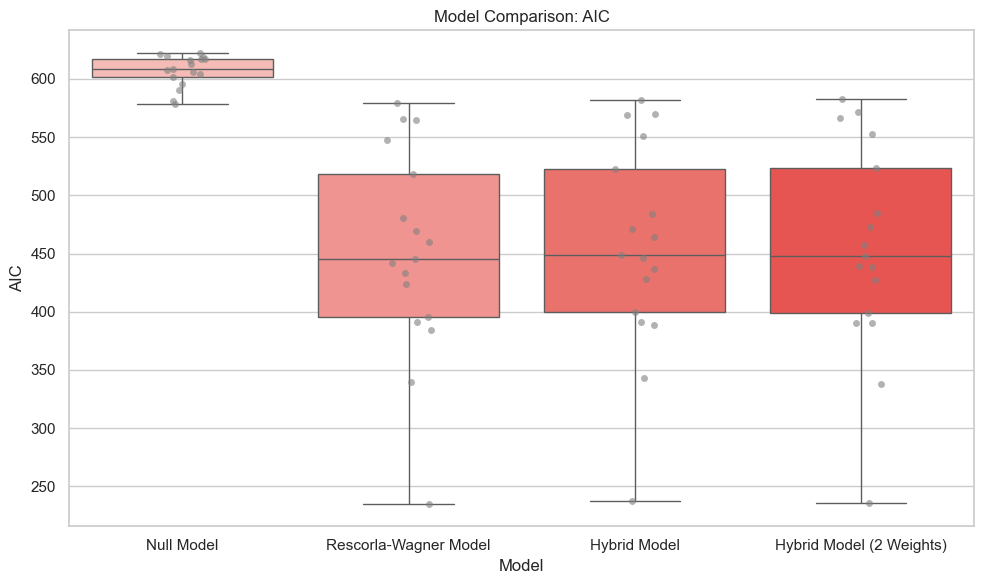

C:\Users\marti\AppData\Local\Temp\ipykernel_27892\1188108473.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="BIC", data=df_melted_bic, palette=bic_palette)


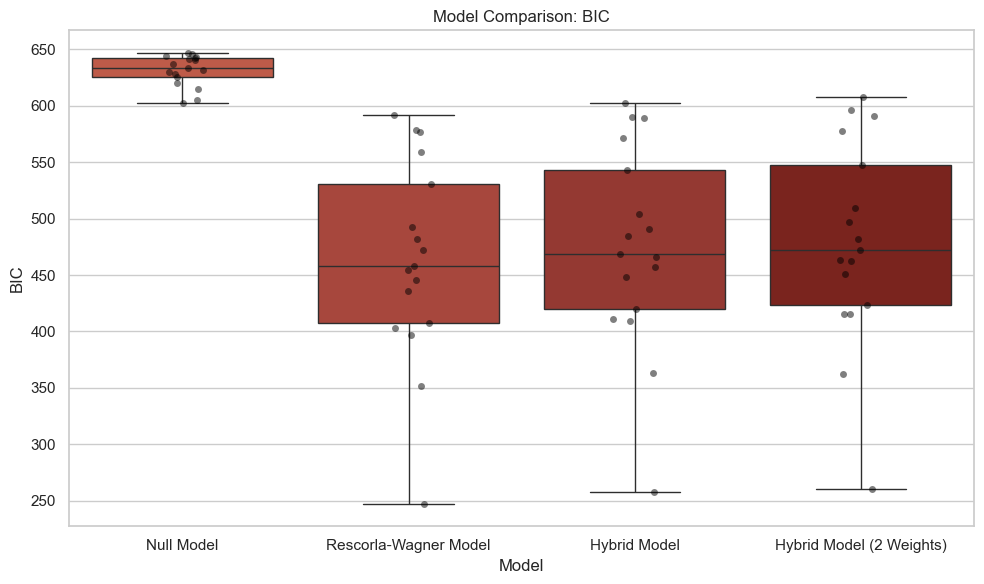

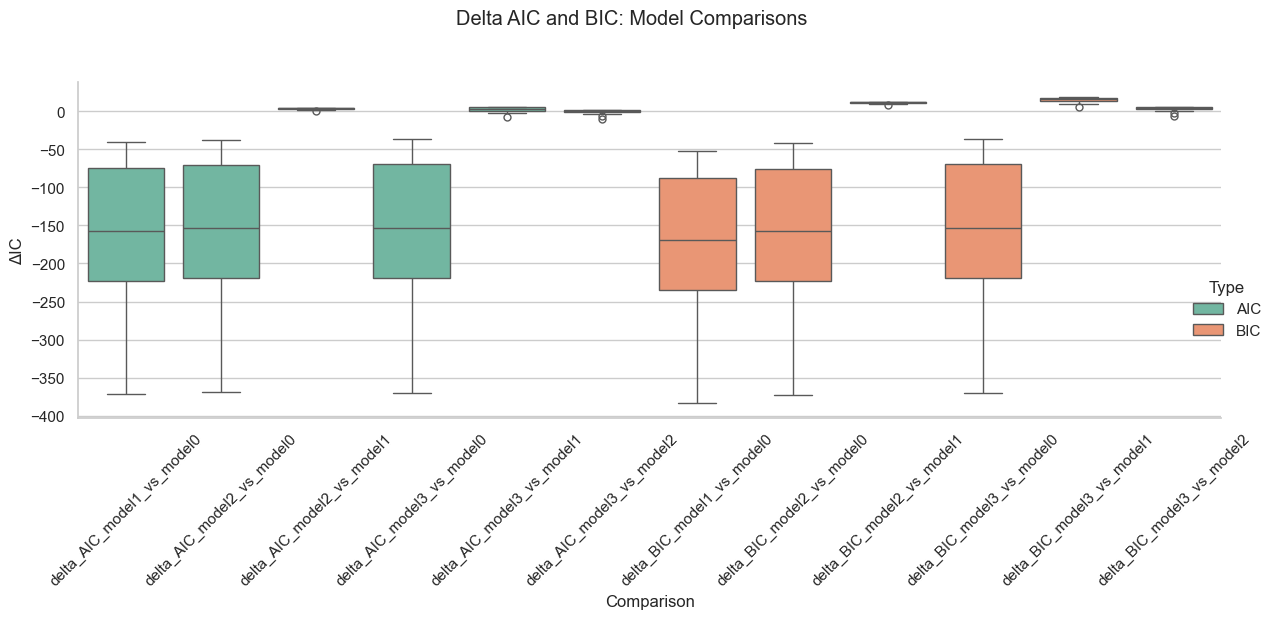

In [ ]:
# Set plotting style
sns.set(style="whitegrid")

# ----- AIC and BIC comparison across models -----

# Melt AIC and BIC columns for easier plotting
aic_cols = ['model0_AIC', 'model1_AIC', 'model2_AIC', 'model3_AIC']
bic_cols = ['model0_BIC', 'model1_BIC', 'model2_BIC', 'model3_BIC']

df_melted_aic = df_learning.melt(id_vars='subject', value_vars=aic_cols, var_name='Model', value_name='AIC')
df_melted_bic = df_learning.melt(id_vars='subject', value_vars=bic_cols, var_name='Model', value_name='BIC')

# Define model name mapping
model_name_map = {
    'model0': 'Null Model',
    'model1': 'Rescorla-Wagner Model',
    'model2': 'Hybrid Model',
    'model3': 'Hybrid Model (2 Weights)'
}

# Clean and rename AIC model labels
df_melted_aic['Model'] = df_melted_aic['Model'].str.replace('_AIC', '', regex=False)
df_melted_aic['Model'] = df_melted_aic['Model'].map(model_name_map)

# Clean and rename BIC model labels
df_melted_bic['Model'] = df_melted_bic['Model'].str.replace('_BIC', '', regex=False)
df_melted_bic['Model'] = df_melted_bic['Model'].map(model_name_map)

# Number of unique models (for palette length)
n_models = df_melted_aic["Model"].nunique()

# AIC: softer red tones (pastel/muted but not pale)
aic_reds = ["#ffb3ad", "#ff8680", "#ff5f57", "#ff3d38", "#ff424b"]
aic_palette = sns.color_palette(aic_reds[:n_models])

# BIC: darker, stronger red tones
bic_reds = ["#d14d36", "#b9382b", "#a42b22", "#89170f", "#730e04"]
bic_palette = sns.color_palette(bic_reds[:n_models])

# AIC Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="AIC", data=df_melted_aic, palette=aic_palette)
sns.stripplot(x="Model", y="AIC", data=df_melted_aic, color='gray', alpha=0.6)
plt.title("Model Comparison: AIC")
plt.tight_layout()
plt.show()

# BIC Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="BIC", data=df_melted_bic, palette=bic_palette)
sns.stripplot(x="Model", y="BIC", data=df_melted_bic, color='black', alpha=0.5)
plt.title("Model Comparison: BIC")
plt.tight_layout()
plt.show()

# ----- Delta AIC/BIC comparisons -----

delta_cols = [
    'delta_AIC_model1_vs_model0', 'delta_AIC_model2_vs_model0', 'delta_AIC_model2_vs_model1',
    'delta_AIC_model3_vs_model0', 'delta_AIC_model3_vs_model1', 'delta_AIC_model3_vs_model2',
    'delta_BIC_model1_vs_model0', 'delta_BIC_model2_vs_model0', 'delta_BIC_model2_vs_model1',
    'delta_BIC_model3_vs_model0', 'delta_BIC_model3_vs_model1', 'delta_BIC_model3_vs_model2',
]

df_melted_delta = df_learning.melt(id_vars='subject', value_vars=delta_cols, var_name='Comparison', value_name='ΔIC')

# Separate AIC and BIC for facet plots
df_melted_delta['Type'] = df_melted_delta['Comparison'].apply(lambda x: 'AIC' if 'AIC' in x else 'BIC')

# Plot ΔIC per comparison
g = sns.catplot(x="Comparison", y="ΔIC", hue="Type", data=df_melted_delta,
                kind="box", height=6, aspect=2, palette='Set2')
g.set_xticklabels(rotation=45)
g.fig.suptitle("Delta AIC and BIC: Model Comparisons", y=1.03)
plt.tight_layout()
plt.show()

C:\Users\marti\AppData\Local\Temp\ipykernel_27892\1397362835.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="AIC", data=df_melted_aic, palette=aic_palette, order=model_order)


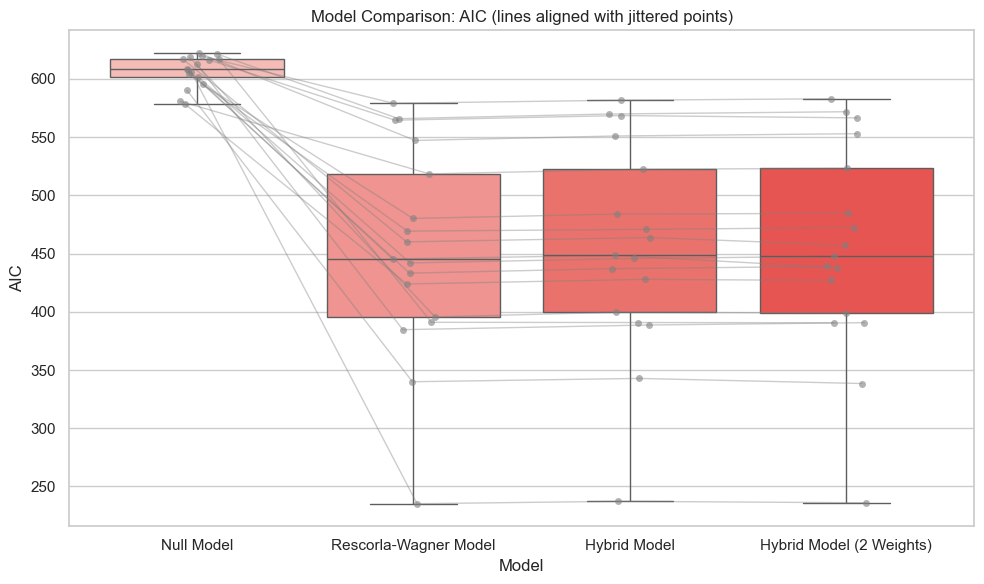

C:\Users\marti\AppData\Local\Temp\ipykernel_27892\1397362835.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="BIC", data=df_melted_bic, palette=bic_palette, order=model_order)


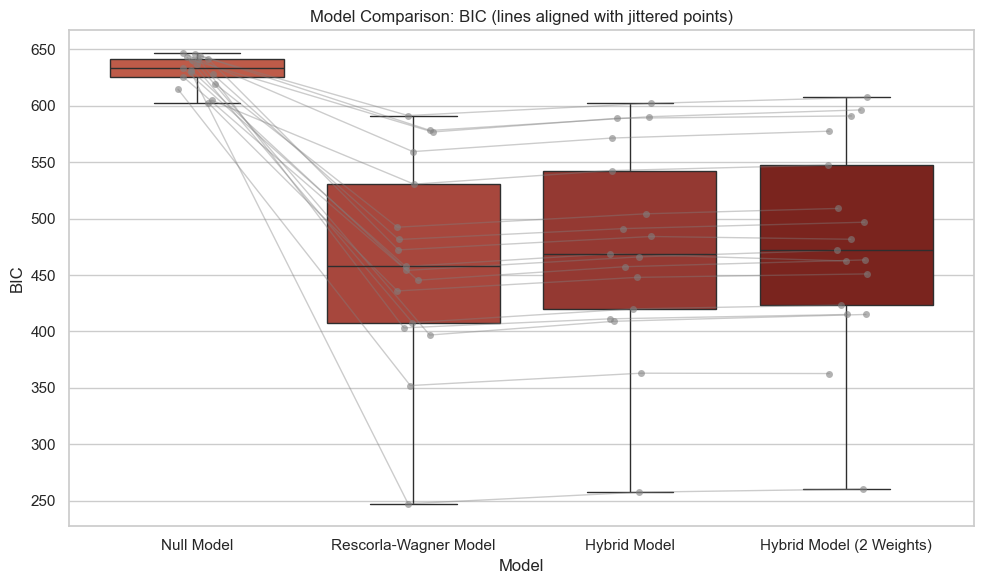

In [ ]:
# Define model order explicitly for consistent plotting
model_order = ["Null Model", "Rescorla-Wagner Model", "Hybrid Model", "Hybrid Model (2 Weights)"]

plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="AIC", data=df_melted_aic, palette=aic_palette, order=model_order)

# Stripplot — keep the object so we can extract coordinates
strip = sns.stripplot(x="Model", y="AIC", data=df_melted_aic, color='gray', alpha=0.6, order=model_order)

# Extract the x/y positions from the scatter points
xy_data = []
for i, artist in enumerate(strip.collections):
    paths = artist.get_offsets()
    xy_data.append(paths)

# Convert to dict: subject → list of (x, y)
subject_points = {}
for i, model in enumerate(model_order):
    model_data = df_melted_aic[df_melted_aic["Model"] == model].reset_index()
    for j, row in model_data.iterrows():
        subj = row["subject"]
        x, y = xy_data[i][j]
        if subj not in subject_points:
            subject_points[subj] = []
        subject_points[subj].append((x, y))

# Draw lines through subject-specific points
for subj, points in subject_points.items():
    if len(points) == len(model_order):
        xs, ys = zip(*sorted(points, key=lambda p: p[0]))  # sort by x-position
        plt.plot(xs, ys, color='gray', alpha=0.4, linewidth=1)

plt.title("Model Comparison: AIC (lines aligned with jittered points)")
plt.tight_layout()
plt.show()


# Plot BIC with similar approach
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="BIC", data=df_melted_bic, palette=bic_palette, order=model_order)

# Stripplot — keep the object so we can extract coordinates
strip = sns.stripplot(x="Model", y="BIC", data=df_melted_bic, color='gray', alpha=0.6, order=model_order)

# Extract the x/y positions from the scatter points
xy_data = []
for i, artist in enumerate(strip.collections):
    paths = artist.get_offsets()
    xy_data.append(paths)

# Convert to dict: subject → list of (x, y)
subject_points = {}
for i, model in enumerate(model_order):
    model_data = df_melted_bic[df_melted_bic["Model"] == model].reset_index()
    for j, row in model_data.iterrows():
        subj = row["subject"]
        x, y = xy_data[i][j]
        if subj not in subject_points:
            subject_points[subj] = []
        subject_points[subj].append((x, y))

# Draw lines through subject-specific points
for subj, points in subject_points.items():
    if len(points) == len(model_order):
        xs, ys = zip(*sorted(points, key=lambda p: p[0]))  # sort by x-position
        plt.plot(xs, ys, color='gray', alpha=0.4, linewidth=1)

plt.title("Model Comparison: BIC (lines aligned with jittered points)")
plt.tight_layout()
plt.show()

C:\Users\marti\AppData\Local\Temp\ipykernel_27892\3553262656.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="AIC", data=df_melted_aic, palette=aic_palette, order=model_order)


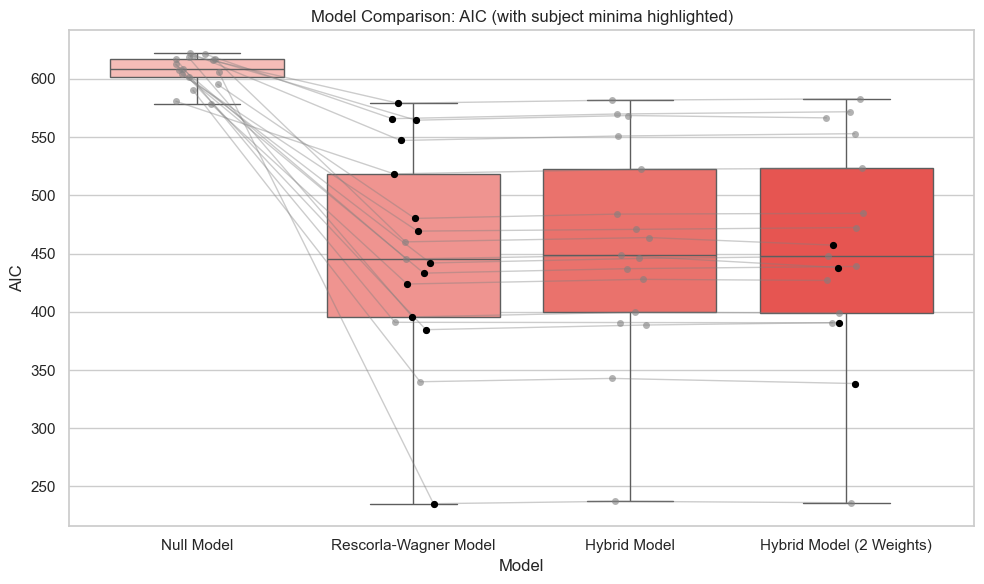

C:\Users\marti\AppData\Local\Temp\ipykernel_27892\3553262656.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="BIC", data=df_melted_bic, palette=bic_palette, order=model_order)


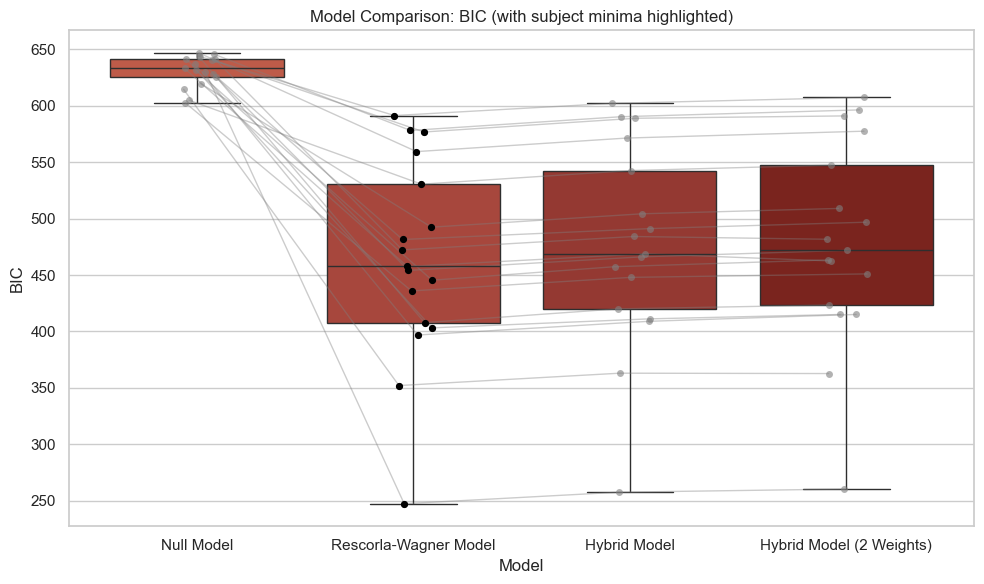

In [ ]:
# --- Highlight AIC minima ---
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="AIC", data=df_melted_aic, palette=aic_palette, order=model_order)
strip = sns.stripplot(x="Model", y="AIC", data=df_melted_aic, color='gray', alpha=0.6, order=model_order)

# Reuse previous logic to extract xy_data
xy_data = []
for i, artist in enumerate(strip.collections):
    paths = artist.get_offsets()
    xy_data.append(paths)

# Rebuild subject_points: subject → list of (x, y)
subject_points = {}
for i, model in enumerate(model_order):
    model_data = df_melted_aic[df_melted_aic["Model"] == model].reset_index()
    for j, row in model_data.iterrows():
        subj = row["subject"]
        x, y = xy_data[i][j]
        if subj not in subject_points:
            subject_points[subj] = []
        subject_points[subj].append((x, y))

# Draw lines and highlight minima
for subj, points in subject_points.items():
    if len(points) == len(model_order):
        xs, ys = zip(*points)
        plt.plot(xs, ys, color='gray', alpha=0.4, linewidth=1)
        # Find index of minimum y (AIC)
        min_idx = ys.index(min(ys))
        plt.scatter(xs[min_idx], ys[min_idx], color="black",
                    s=70, marker='.', zorder=5, label='_nolegend_')  # _nolegend_ avoids duplicate legend entries

plt.title("Model Comparison: AIC (with subject minima highlighted)")
plt.tight_layout()
plt.show()


# --- Highlight BIC minima ---
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="BIC", data=df_melted_bic, palette=bic_palette, order=model_order)
strip = sns.stripplot(x="Model", y="BIC", data=df_melted_bic, color='gray', alpha=0.6, order=model_order)

# Reuse previous logic to extract xy_data
xy_data = []
for i, artist in enumerate(strip.collections):
    paths = artist.get_offsets()
    xy_data.append(paths)

# Rebuild subject_points: subject → list of (x, y)
subject_points = {}
for i, model in enumerate(model_order):
    model_data = df_melted_bic[df_melted_bic["Model"] == model].reset_index()
    for j, row in model_data.iterrows():
        subj = row["subject"]
        x, y = xy_data[i][j]
        if subj not in subject_points:
            subject_points[subj] = []
        subject_points[subj].append((x, y))

# Draw lines and highlight minima
for subj, points in subject_points.items():
    if len(points) == len(model_order):
        xs, ys = zip(*points)
        plt.plot(xs, ys, color='gray', alpha=0.4, linewidth=1)
        # Find index of minimum y (BIC)
        min_idx = ys.index(min(ys))
        plt.scatter(xs[min_idx], ys[min_idx], color="black",
                    s=70, marker='.', zorder=5, label='_nolegend_')  # _nolegend_ avoids duplicate legend entries

plt.title("Model Comparison: BIC (with subject minima highlighted)")
plt.tight_layout()
plt.show()